# Notebook 8 – Dynamic CBA with AC Waste-Heat Feedback

> **Goal.** Extend the city-level cost–benefit analysis (CBA) for urban heat adaptation by combining dynamic **trees** and **AC** policies with an explicit **AC waste-heat feedback** on outdoor temperature and mortality, and by exploring optimal policy mixes under a PV budget constraint.

---

## Overview

- **Inputs**
  - City configuration and file paths (config YAML).
  - Population trajectories from `exposure_manifest` (for dynamic exposure).
  - Tree policy table (ΔGVI by municipality) and UrbClim-based cooling fields.
  - AC coverage and kWh per user by municipality over time.
  - Impact outputs from previous notebooks:
    - Baseline heat-attributable deaths under current AC.
    - Marginal deaths per °C from a +1°C perturbation.
    - Annual avoided deaths for trees, AC, and both.

- **Setup**
  - Horizon: **25 years**; discount rate: **3%**.
  - Helper functions for present value (PV) and equivalent annual cost (EAC).
  - Population and AC coverage evolve dynamically over time.

---

## Tree module (ΔGVI to costs and benefits)

- Convert the tree policy’s ΔGVI into **index points (1–100 scale)** and apply:
  - **CAPEX per index point** (based on per-tree costs).
  - **O&M per index point per year**, with a tree lifetime.
- Model **linear rollout** over the horizon and **maturity ramp** (12 years), with:
  - Central case: pre-grown trees (start age ≈ 5 years).
  - Alternative timing conventions for when O&M starts.
- Compute:
  - PV(CAPEX), PV(O&M), PV(total) and corresponding EACs.
  - A **high-O&M sensitivity** where PV(O&M) = 5 × PV(CAPEX).

---

## AC module (dynamic costs and waste-heat feedback)

- Build **dynamic AC coverage** by municipality and year, including:
  - Time-varying municipal populations (from exposure scenario).
  - Interpolated **kWh/user** series for electricity use.
- Compute AC policy **costs**:
  - CAPEX with replacement cycles.
  - Annual maintenance (as a fraction of CAPEX).
  - Electricity costs from incremental kWh and a tariff (€/kWh).
- Introduce **AC waste-heat feedback** using literature-based warming:
  - Lookup table of nighttime ΔT vs AC penetration (0–100%).
  - Interpolate to the city’s penetration trajectory, then convert to
    **daily-mean ΔT** by halving (from nighttime to daily mean).
  - Report **absolute warming vs “no waste heat”** and **incremental warming (policy − baseline)**.

---

## Benefits and waste-heat penalty

- Load annual **avoided deaths** (trees, AC, both, trees-on-top-of-AC) and:
  - Interpolate to a full 25-year horizon.
  - Apply the **tree rollout + maturity factor** to obtain dynamic tree benefits.
- Convert **waste-heat ΔT** into **extra heat deaths** using marginal deaths per °C:
  - Extra deaths = (marginal deaths / °C) × (incremental daily-mean ΔT).
  - Subtract this penalty from AC benefits to get **net AC benefits**.
- Produce both **gross** (no feedback) and **net** (with feedback) summaries:
  - Cumulative and PV avoided deaths for trees only, AC only, both, and trees-on-top.
  - Percentage reductions vs baseline mortality under current AC.

---

## Trees vs AC waste heat

- Compare **tree cooling** (°C) to **AC waste-heat warming** in:
  - Temperature space (pop-weighted ΔT over time).
  - Health space (avoided vs extra deaths).
- Quantify how much AC waste heat **erodes tree benefits**:
  - Shares of tree and tree-on-top benefits lost in cumulative and PV terms.
  - Diagnostics of years where the incremental penalty exceeds tree-on-top benefits.

---

## Budget optimisation and policy mixes

- Treat “full trees” and “full AC policy” as **unit interventions** with:
  - Known PV costs: PV\_trees, PV\_AC.
  - Known 25-year net benefits (avoided deaths): BEN\_trees, BEN\_AC.
- Under a **PV budget**, evaluate all linear (for now, would be interesting to look at non-linear later) mixes of trees and AC:
  - Enumerate feasible combinations (shares of trees and AC).
  - Identify:
    - The mix that **maximizes avoided deaths**.
    - The mix that **minimizes cost per avoided death** (subject to a minimum benefit fraction).
- Compute and plot:
  - The **Pareto frontier** (cost vs avoided deaths).
  - **Incremental cost-effectiveness ratios (ICERs)** along the frontier.
  - Sensitivity of optimal mixes to the **budget level**.
  - Alternative scenarios with **policy constraints**:
    - Minimum tree share (e.g. for co-benefits).
    - Maximum AC share (e.g. for equity/fairness considerations).

---

**Key outputs**

- PV and EAC for tree and AC policies under multiple assumptions.
- Time series of **AC penetration**, **waste-heat warming**, and **extra deaths**.
- Dynamic and static **health benefits** for trees, AC, and their combination.
- Summary tables and figures for:
  - Cost per avoided death by policy.
  - Budget-feasible mixes and their effectiveness.
  - Pareto frontier and ICERs.
  - Sensitivity of optimal policy mixes to budgets and constraints.

**New point: The feedback of AC on temperature**
- Air conditioning systems work by extracting heat from indoor spaces and rejecting it outdoors. This waste heat warms the ambient outdoor air temperature, creating a positive feedback loop: Higher outdoor T → More AC demand → More waste heat → Even higher outdoor T.
  
- This effect is disproportionately strong at night because:
    - During daytime: The deep convective boundary layer (1–3 km) disperses waste heat
      efficiently
    - During nighttime: The shallow stable boundary layer (100–300 m) traps waste heat
      near the surface

- **Implementation**:
- adds an AC waste-heat externality term to the policy scenarios: Net AC benefits = Avoided deaths from indoor cooling − Extra deaths from outdoor warming
- switchable sensitivity
    - On/off toggle via DELTA_T_CASE = "off" | "low" | "central" | "high"
    - Configurable driver: DELTA_T_DRIVER = "kwh" | "users"
- Nighttime → Daily-mean conversion (HALVING THE EFFECT):
The literature reports nighttime warming (0.5–1.0°C), but our hazard uses daily-mean T2M.
Since daily mean ≈ (Tmax + Tmin)/2 and AC waste heat only warms Tmin (night), we must halve the literature values:
    - Literature nighttime:  low=0.50°C,  central=0.75°C,  high=1.00°C
    - Applied daily-mean:    low=0.25°C,  central=0.375°C, high=0.50°C
- Incremental approach for CBA: We compute the incremental externality (policy − baseline), not absolute warming, because both scenarios have some waste-heat impact.
- Linear scaling with AC activity: We scale warming linearly with kWh consumption (or users), capped at the literature maximum.

In [1]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [3]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [4]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

- Trees policy table and citywide ΔGVI diagnostics (sum of Municipi)
- AC coverage maps + population grid
- Municipality-level coverage and kWh/user outputs from earlier notebooks
- AC efficacy by age (used on benefit side)

In [5]:
# loading everything needed for the CBA
from pathlib import Path
import json
import numpy as np
import pandas as pd

OUT = Path(OUT)
INT = Path(INT)
TAB_DIR = OUT / "tables"

# Vegetation policy / ΔGVI
trees_tbl = pd.read_csv(TAB_DIR / f"{SLUG}_trees_tbl.csv")

# diagnostics JSON with citywide ΔGVI (pop-weighted, points on 1–100 scale)
veg_diag_path = OUT / f"{SLUG}_veg_diagnostics.json"
veg_diag = json.loads(veg_diag_path.read_text())
citywide_dGVI_points_popw = veg_diag["citywide_dGVI_points_popw"]
print("Citywide pop-weighted ΔGVI (points, 1–100 scale):", citywide_dGVI_points_popw)

# AC coverage / municipal pop / energy use
# coverage maps
ac_cov_npz = np.load(INT / f"ac_coverage_maps_{SLUG}.npz")
coverage_base_3d   = ac_cov_npz["coverage_base_3d"]
coverage_policy_3d = ac_cov_npz["coverage_policy_3d"]
YEARS_AC           = ac_cov_npz["YEARS_AC"]
CITY_MASK = ac_cov_npz["CITY_MASK"].astype(bool)
HGT = int(ac_cov_npz["HGT"])
WDT = int(ac_cov_npz["WDT"])

# population on ref grid
pop_npz = np.load(INT / f"pop_on_ref_{SLUG}.npz")
pop_on_ref = pop_npz["pop"]

# municipio coverage table (pop_muni, ac_base_muni, ac_policy_muni)
muni_cov = pd.read_csv(OUT / f"muni_cov_{SLUG}.csv")

# AC consumption per municipality (kWh per AC user)
muni_tbl_all = pd.read_csv(OUT / f"{SLUG}_muni_ac_consumption_summary.csv")

# AC efficacy by age (for benefits, not directly cost-side)
eff_buckets_path = INT / f"ac_eff_buckets_{SLUG}.json"
EFF_BUCKETS = json.loads(eff_buckets_path.read_text())
EFF_BUCKETS

Citywide pop-weighted ΔGVI (points, 1–100 scale): 2.3197


{'<15': 0.3, '15-64': 0.4, '65+': 0.55}

In [6]:
import json
import numpy as np

# loading exposure_manifest and build citywide pop totals by year (as usual since our population changes over time!)
manifest_path = INT / "exposure_manifest.json"
pop_total_for_year = None  # will be set below

if manifest_path.exists():
    expo_manifest = json.loads(manifest_path.read_text())

    # scenario key from YAML (e.g. "SSP2", "SSP2DM", ...)
    exp_scen_raw = cfg.get("exp_scenario", "SSP2")

    # trying to match it to the manifest keys 
    scen_keys = list(expo_manifest.get("scenarios", {}).keys())

    def _match_scenario(exp_scen, keys):
        # exact
        if exp_scen in keys:
            return exp_scen
        # upper
        up = exp_scen.upper()
        if up in keys:
            return up
        # 3) strip '-', '_' characters (e.g. "SSP2-DM" -> "SSP2DM")
        cleaned = up.replace("-", "").replace("_", "")
        for k in keys:
            if k.replace("-", "").replace("_", "").upper() == cleaned:
                return k
        raise KeyError(f"Could not match exp_scenario={exp_scen!r} to manifest scenarios {keys}")

    scen_key = _match_scenario(exp_scen_raw, scen_keys)
    print(f"[exposure_manifest] Using scenario key: {scen_key!r}")

    # collecting pop grids for this scenario
    scen_dict = expo_manifest["scenarios"][scen_key]
    pop_on_ref_by_year = {}
    for year_str, rec in scen_dict.items():
        y = int(year_str)
        pop_npz = np.load(rec["pop_npz"])
        pop_on_ref_by_year[y] = pop_npz["pop"].astype("float32")

    known_years = sorted(pop_on_ref_by_year.keys())
    known_totals = np.array([pop_on_ref_by_year[y].sum() for y in known_years], dtype=float)

    print("Known exposure years:", known_years)
    print("Citywide pop totals:", [int(t) for t in known_totals])

    def pop_total_for_year(y: int | float) -> float:
        """Interpolate total population for any year using exposure_manifest."""
        return float(np.interp(y, known_years, known_totals))

else:
    print("WARNING: exposure_manifest.json not found; using fixed 2030 pop for AC costs.")
    # fallback will be set once pop_on_ref is loaded later
    pop_total_for_year = None

[exposure_manifest] Using scenario key: 'SSP2'
Known exposure years: [2030, 2040, 2050]
Citywide pop totals: [2548153, 2488442, 2439832]


**Discount helpers**

- Set discount rate R and horizon T
- Define PV helpers and annuity factor (PV -> equivalent annual cost)
- Convention: flows are treated as end-of-year (years 1..T)

In [7]:
import numpy as np

R = 0.03 # discount rate
T = 25 # time horizon

TREE_RAMP_YEARS = 12          # maturity ramp for both benefits and O&M
TREE_START_AGE_CENTRAL = 5    # central case (pre-grown trees)
TREE_START_AGE_SENS = 0       # sensitivity 

TREE_START_AGE_YEARS = TREE_START_AGE_CENTRAL  # the one used by the model by default

# Convention: all flows occur at END of each year => years 1..T
# present value (PV) of a constant annual flow over T years.
def pv_level_flow(annual, r=R, T=T):
    """PV of a constant annual amount paid in years 1..T."""
    yrs = np.arange(1, T+1, dtype=float)
    return float(np.sum(annual * (1 + r) ** (-yrs)))

# PV of buying an item at t=0 and then replacing it every 'life' years within the horizon.
def pv_replacements(n_items, capex_per_item, r=R, T=T, life=20):
    """ PV of buying 'n_items' at t=0 and replacing every 'life' years within horizon T. """
    pv = 0.0
    t = 0
    while t <= T:
        pv += n_items * capex_per_item / ((1+r)**t if t > 0 else 1.0)
        t += life
    return float(pv)

# annuity_factor: present value of "1 euro per year" over T years. We later use this
# to convert any PV into a constant equivalent annual cost (EAC).
def annuity_factor(r=R, T=T):
    return (1 - (1 + r) ** (-T)) / r

AF = annuity_factor(R, T)
AF

17.413147691278027

In [8]:
def pv_capex_with_ramp(new_users_t, capex_per_user, life, r=R):
    """ PV of AC capex when policy coverage ramps up over time.

    new_users_t: 1D array length T, number of new policy users in each year (vs baseline).
    capex_per_user: installation cost per AC user.
    life: years between replacements.
    r: discount rate.

    For each cohort of new users in year t, we:
    - pay capex once at installation (year t+1 in our convention)
    - then pay the same capex again every life years (replacement)
    - discount each of these payments back to year 0 and sum them up.
    """
    T = len(new_users_t)
    pv = 0.0
    for t in range(T):  # t = 0..T-1 corresponds to years 1..T
        cohort = float(new_users_t[t])
        if cohort <= 0:
            continue
        pay_year = t  # installation in year t+1, then every 'life' years
        while pay_year < T:
            pv += cohort * capex_per_user / ((1 + r) ** (pay_year + 1))
            pay_year += life
    return float(pv)

**Trees: parametrisation of costs**

- Convert ΔGVI to “index points” and apply €/index-point CAPEX
- CAPEX: linear rollout over T years
- O&M: starts the year after planting and scales with maturity (ramp years)
- start_age shifts maturity (central=5, sensitivity=0)

- Compare alternative conventions:
    - A) O&M starts immediately (old)
    - B) O&M starts next year
    - C) O&M starts next year + maturity-scaled (current best practice)

In [9]:
# para from rule (working paper) and regreen study
CAPEX_PER_INDEX_PT = 10_000_000.0  # eur per 1 index point (1–100 scale)

# converting per-tree CAPEX and per-tree O&M into an O&M cost per GVI point.
CAPEX_PER_TREE = 210.0    # eur per tree (REGREEN median)
OM_PER_TREE_YR = 27.0     # eur per tree per year
LIFETIME_YEARS = 25       # tree benefit/O&M lifetime

# O&M per index point per year implied by tree-level numbers
OM_PER_INDEX_PT_YR = (OM_PER_TREE_YR / CAPEX_PER_TREE) * CAPEX_PER_INDEX_PT
print("O&M per index point per year (EUR):", round(OM_PER_INDEX_PT_YR, 0))

# Total change in GVI in index point (1–100 SCALE) from trees_tbl
# trees_tbl['dGVI'] is in 0–1 (fraction of max index); sum over Municipi, then ×100 => points
DELTA_INDEX = float(trees_tbl["dGVI"].clip(lower=0).sum()) * 100.0  # sum of municipio dGVI (0–1) => index points (0–100)
print("Total ΔGVI index points (1–100 scale):", round(DELTA_INDEX, 2))

# for comparison: citywide pop-weighted ΔGVI (diagnostics)
print("Pop-weighted ΔGVI points (diagnostic):", citywide_dGVI_points_popw)

# CAPEX: linear ramp over T years
# linear rollout over 25 years
# each year we add (ΔGVI / 25) points
# pay CAPEX once for that increment in that year
# investment schedule(t) = 10M€ * (ΔGVI/25) every year, discounted year by year.
def npv_capex_linear(delta_index_total, years=T, r=R, capex_per_index=CAPEX_PER_INDEX_PT):
    """
    PV of a linear ramp: we add delta_index_total/years index points each year over 'years',
    and pay capex_per_index per point.
    All flows are assumed at the end of years 1..years.
    """
    inc = delta_index_total / years  # index points added per year
    pv = 0.0
    for t in range(1, years + 1):  # t = 1..years
        capex_t = capex_per_index * inc
        pv += capex_t / ((1 + r) ** t)
    return float(pv)

# paper-style "investment requirement" if all done at once (cf working paper still)
TREES_CAPEX_T0 = CAPEX_PER_INDEX_PT * DELTA_INDEX

PV_trees_capex = npv_capex_linear(DELTA_INDEX, years=T, r=R, capex_per_index=CAPEX_PER_INDEX_PT)
print(f"Trees — Total CAPEX requirement (undiscounted): €{TREES_CAPEX_T0:,.0f}")
print(f"Trees — NPV CAPEX (linear ramp): €{PV_trees_capex:,.0f}")

# annuity factor
AF = annuity_factor(R, T)

# O&M that starts the year AFTER planting, and scales up with maturity (like benefits)
def cohort_rollout_maturity_factor_om(T, ramp_years, plant_share=None, lifetime=25, start_age_years=0):
    """
    factor[t] = sum_i plant_share[i] * maturity(age=t-i), where
      - planting year (age=0) has maturity forced to 0 => O&M starts at t+1
      - from age>=1, maturity is shifted by start_age_years (pre-grown trees)
    """
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T
    max_age = min(T, lifetime)
    ages = np.arange(max_age + 1, dtype=float)  # 0..max_age
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # no O&M in planting year
    return np.convolve(plant_share, maturity)[:T]

def npv_om_cohorts_scaled(delta_index_total, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
                         ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS, start_age_years=0):
    plant_share = np.ones(years, dtype=float) / years
    factor_om = cohort_rollout_maturity_factor_om(
        T=years, ramp_years=ramp_years, plant_share=plant_share,
        lifetime=lifetime, start_age_years=start_age_years
    )
    om_stream = om_per_index_per_year * delta_index_total * factor_om
    yrs = np.arange(1, years + 1, dtype=float)
    pv = float(np.sum(om_stream * (1 + r) ** (-yrs)))
    return pv, om_stream

# calling with the new shift
PV_trees_om, om_stream_scaled = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
    ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS,
    start_age_years=TREE_START_AGE_YEARS,
)

PV_trees_total = PV_trees_capex + PV_trees_om
EAC_capex_annuity = PV_trees_capex / AF
EAC_om_annuity = PV_trees_om / AF
EAC_total_annuity = PV_trees_total / AF

TREES_CAPEX_T0 = CAPEX_PER_INDEX_PT * DELTA_INDEX
EAC_capex_paper = TREES_CAPEX_T0 / ((1 + R)**T * T)

print(f"Trees — NPV O&M (scaled with maturity): €{PV_trees_om:,.0f}")
print(f"Trees — NPV total (CAPEX + O&M): €{PV_trees_total:,.0f}")
print(f"Trees — EAC CAPEX (annuity): €{EAC_capex_annuity:,.0f}/yr")
print(f"Trees — EAC O&M (annuity): €{EAC_om_annuity:,.0f}/yr")
print(f"Trees — EAC total (annuity): €{EAC_total_annuity:,.0f}/yr")

O&M per index point per year (EUR): 1285714.0
Total ΔGVI index points (1–100 scale): 30.23
Pop-weighted ΔGVI points (diagnostic): 2.3197
Trees — Total CAPEX requirement (undiscounted): €302,333,765
Trees — NPV CAPEX (linear ramp): €210,583,300
Trees — NPV O&M (scaled with maturity): €243,071,452
Trees — NPV total (CAPEX + O&M): €453,654,752
Trees — EAC CAPEX (annuity): €12,093,351/yr
Trees — EAC O&M (annuity): €13,959,076/yr
Trees — EAC total (annuity): €26,052,427/yr


In [10]:
print("om_stream first 5:", np.round(om_stream_scaled[:5], 2))
print("om_stream last  5:", np.round(om_stream_scaled[-5:], 2))
print("om_stream max:", float(np.max(om_stream_scaled)))
print("om_stream last:", float(om_stream_scaled[-1]))

om_stream first 5: [      0.    777429.68 1684430.98 2721003.89 3887148.41]
om_stream last  5: [28376183.38 29931042.74 31485902.1  33040761.47 34595620.83]
om_stream max: 34595620.83108466
om_stream last: 34595620.83108466


In [11]:
import numpy as np
import pandas as pd

def pv_from_stream(stream, r, T):
    yrs = np.arange(1, T+1, dtype=float)
    return float(np.sum(np.asarray(stream, float) * (1 + r) ** (-yrs)))

def om_stream_constant(delta_index_total, om_per_index_per_year, T, include_planting_year: bool):
    # Constant O&M per cohort (no maturity scaling)
    inc = delta_index_total / T
    stream = np.zeros(T, dtype=float)
    for t in range(1, T+1):  # cashflows in years 1..T
        active = (t if include_planting_year else max(t-1, 0))
        stream[t-1] = active * om_per_index_per_year * inc
    return stream

def om_stream_scaled(delta_index_total, om_per_index_per_year, T, ramp_years):
    # Scaled with “maturity”, and zero in planting year by construction
    plant_share = np.ones(T, dtype=float) / T
    ages = np.arange(T+1, dtype=float)  # 0..T
    maturity = np.minimum(ages / ramp_years, 1.0)  # age 0 => 0
    factor = np.convolve(plant_share, maturity)[:T]
    return om_per_index_per_year * delta_index_total * factor

TREE_OM_RAMP_YEARS = TREE_RAMP_YEARS

# very old convention: O&M starts immediately
sA = om_stream_constant(DELTA_INDEX, OM_PER_INDEX_PT_YR, T, include_planting_year=True)
PV_A = pv_from_stream(sA, R, T)

# point 1: O&M starts the year after planting
sB = om_stream_constant(DELTA_INDEX, OM_PER_INDEX_PT_YR, T, include_planting_year=False)
PV_B = pv_from_stream(sB, R, T)

# point 2: O&M starts next year AND scales with maturity
sC = om_stream_scaled(DELTA_INDEX, OM_PER_INDEX_PT_YR, T, ramp_years=TREE_OM_RAMP_YEARS)
PV_C = pv_from_stream(sC, R, T)

rows = []
for name, PV_om, stream in [
    ("A) O&M starts same year (old)", PV_A, sA),
    ("B) O&M starts next year", PV_B, sB),
    ("C) O&M next year + maturity-scaled", PV_C, sC),
]:
    PV_total = PV_trees_capex + PV_om
    rows.append({
        "scenario": name,
        "PV_capex": PV_trees_capex,
        "PV_om": PV_om,
        "PV_total": PV_total,
        "EAC_capex": PV_trees_capex / AF,
        "EAC_om": PV_om / AF,
        "EAC_total": PV_total / AF,
        "PV_om_over_PV_capex": PV_om / PV_trees_capex,
        "OM_year1": stream[0],
        "OM_yearT": stream[-1],
    })

compare_om = pd.DataFrame(rows)
compare_om

,scenario,PV_capex,PV_om,PV_total,EAC_capex,EAC_om,EAC_total,PV_om_over_PV_capex,OM_year1,OM_yearT
0,A) O&M starts same year (old),2.105833e+08,3.107336e+08,5.213169e+08,1.209335e+07,1.784477e+07,2.993812e+07,1.475585,1.554859e+06,3.887148e+07
1,B) O&M starts next year,2.105833e+08,2.836586e+08,4.942419e+08,1.209335e+07,1.628991e+07,2.838326e+07,1.347014,0.000000e+00,3.731662e+07
2,C) O&M next year + maturity-scaled,2.105833e+08,1.682367e+08,3.788200e+08,1.209335e+07,9.661474e+06,2.175482e+07,0.798908,0.000000e+00,2.876490e+07


- Trees O&M sensitivity: force PV(O&M) = 5 × PV(CAPEX)
   - Compute multiplier on O&M rate so the PV ratio hits the target
   - Used for “high O&M” sensitivity cases in summary tables

In [12]:
# point 3: sensitivity where PV(O&M) = 5 * PV(CAPEX) under the SAME timing convention
TARGET_OM_TO_CAPEX_PV_RATIO = 5.0  # sensitivity

# baseline under scenario C (O&M starts next year + maturity scaling)
PV_om_base, om_stream_base = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
    ramp_years=TREE_OM_RAMP_YEARS, lifetime=LIFETIME_YEARS
)

# scale factor to hit target PV ratio
k = (TARGET_OM_TO_CAPEX_PV_RATIO * PV_trees_capex) / PV_om_base
OM_PER_INDEX_PT_YR_5x = OM_PER_INDEX_PT_YR * k

PV_om_5x, om_stream_5x = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR_5x,
    ramp_years=TREE_OM_RAMP_YEARS, lifetime=LIFETIME_YEARS
)

print("O&M sensitivity scaling (scenario C timing):")
print(f" PV(CAPEX) = €{PV_trees_capex:,.0f}")
print(f" Base PV(O&M) = €{PV_om_base:,.0f}")
print(f" Target PV(O&M) = €{TARGET_OM_TO_CAPEX_PV_RATIO * PV_trees_capex:,.0f}")
print(f" Multiplier k on OM rate = {k:.2f}x")
print(f" New PV(O&M) = €{PV_om_5x:,.0f}")

# optional: EAC comparison
print(f" Base EAC(O&M) = €{PV_om_base/AF:,.0f}/yr")
print(f" New EAC(O&M) = €{PV_om_5x/AF:,.0f}/yr")

O&M sensitivity scaling (scenario C timing):
 PV(CAPEX) = €210,583,300
 Base PV(O&M) = €168,236,674
 Target PV(O&M) = €1,052,916,501
 Multiplier k on OM rate = 6.26x
 New PV(O&M) = €1,052,916,501
 Base EAC(O&M) = €9,661,474/yr
 New EAC(O&M) = €60,466,753/yr


**Cost AC**

- AC cost model (dynamic coverage + dynamic kWh/user)
  - Coverage ramps by municipality over time (policy - baseline)
  - New users cohorts drive CAPEX and replacement cycles
  - Ongoing costs: maintenance + electricity (kWh/user interpolated over horizon)

In [13]:
# Dynamic AC horizon years (aligned with NB7 / CLIMADA outputs)
# We only need the start year and the list of years for the CBA horizon.
ac_city_series = pd.read_csv(INT / f"ac_per_user_city_{SLUG}.csv")
ac_city_series = ac_city_series.set_index("year").sort_index()
ELEC_START_YEAR = int(ac_city_series.index.min()) # should be 2030
ELEC_YEARS = np.arange(ELEC_START_YEAR, ELEC_START_YEAR + T, dtype=int)

In [14]:
# AC COSTS: dynamic coverage + dynamic kWh/user (+ incremental waste-heat change in T)
AC_CAPEX_PER_USER   = 500.0   # € per AC unit
AC_MAINT_RATE       = 0.05    # fraction of CAPEX per year
AC_LIFETIME_YEARS   = 10      # replacement cycle
TARIFF_EUR_PER_KWH  = 0.25    # €/kWh

maint_per_user_yr = AC_MAINT_RATE * AC_CAPEX_PER_USER

# electricity-horizon years (need to keep them separate from benefits YEARS later)
ELEC_YEARS = ELEC_YEARS.copy()
assert len(ELEC_YEARS) == T

# Municipio level coverage over time
try:
    muni_cov_all = pd.read_csv(OUT / f"{SLUG}_muni_cov_yearly.csv")
except FileNotFoundError:
    muni_cov_all = muni_cov.copy()

if "muni_id" in muni_cov_all.columns:
    muni_cov_all = muni_cov_all.loc[muni_cov_all["muni_id"] > 0].copy()

rows = []
for muni_id, g in muni_cov_all.groupby("muni_id"):
    g = g.sort_values("year")
    known_years = g["year"].to_numpy(int)

    known_base = g["ac_base_muni"].to_numpy(float)
    known_pol  = g["ac_policy_muni"].to_numpy(float)

    # Baseline (2030) municipal population
    pop_2030 = float(g["pop_muni"].iloc[0])

    # Citywide scaling factor for each year
    pop_2030_total = pop_total_for_year(2030)
    pop_scale_t = np.array(
        [pop_total_for_year(y) / pop_2030_total for y in ELEC_YEARS],
        dtype=float,
    )
    pop_muni_t = pop_2030 * pop_scale_t  # same relative growth for all municipi

    # interpolatating AC shares for each year
    base_t = np.interp(ELEC_YEARS, known_years, known_base)
    pol_t  = np.interp(ELEC_YEARS, known_years, known_pol)

    # flat before first known year and after last known year
    base_t[ELEC_YEARS <= known_years[0]] = known_base[0]
    base_t[ELEC_YEARS >= known_years[-1]] = known_base[-1]
    pol_t[ELEC_YEARS <= known_years[0]]   = known_pol[0]
    pol_t[ELEC_YEARS >= known_years[-1]]  = known_pol[-1]

    base_t = np.clip(base_t, 0.0, 1.0)
    pol_t  = np.clip(pol_t, 0.0, 1.0)
    dshare_t = np.clip(pol_t - base_t, 0.0, 1.0)

    for year, bs, ps, ds, pm in zip(ELEC_YEARS, base_t, pol_t, dshare_t, pop_muni_t):
        rows.append({
            "year": int(year),
            "muni_id": muni_id,
            "pop_muni": float(pm),  # now time-varying
            "base_share_t": float(bs),
            "policy_share_t": float(ps),
            "dshare_t": float(ds),
        })

cov_yearly = pd.DataFrame(rows)
cov_yearly["year"] = cov_yearly["year"].astype(int)

# users: baseline vs policy -> incremental users + cohorts 
users_base_t = (
    cov_yearly.assign(users=lambda d: d["pop_muni"] * d["base_share_t"])
    .groupby("year")["users"].sum()
    .reindex(ELEC_YEARS).to_numpy(float)
)

users_policy_t = (
    cov_yearly.assign(users=lambda d: d["pop_muni"] * d["policy_share_t"])
    .groupby("year")["users"].sum()
    .reindex(ELEC_YEARS).to_numpy(float)
)

added_users_t = users_policy_t - users_base_t  # incremental (can be negative in theory)
new_users_t = np.empty_like(added_users_t)
new_users_t[0] = added_users_t[0]
new_users_t[1:] = added_users_t[1:] - added_users_t[:-1]
new_users_t = np.maximum(new_users_t, 0.0)     # cohorts must be non-negative

added_users_final = float(added_users_t[-1])
print(f"AC — added users in final year ≈ {added_users_final:,.0f}")

# kWh/user by municipality -> interpolate to full horizon 
muni_tbl_all = pd.read_csv(OUT / f"{SLUG}_muni_ac_consumption_summary.csv")
rows_kwh = []
for muni_id, g in muni_tbl_all.groupby("muni_id"):
    g = g.sort_values("year")
    known_years = g["year"].to_numpy(int)
    vals = g["kwh_per_user_muni"].to_numpy(float)

    kwh_interp = np.interp(ELEC_YEARS, known_years, vals)
    kwh_interp[ELEC_YEARS <= known_years[0]] = vals[0]
    kwh_interp[ELEC_YEARS >= known_years[-1]] = vals[-1]

    for y, v in zip(ELEC_YEARS, kwh_interp):
        rows_kwh.append({
            "year": int(y),
            "muni_id": muni_id,
            "kwh_per_user_muni": float(v),
        })

muni_kwh_full = pd.DataFrame(rows_kwh)
cov_yearly = (
    cov_yearly.merge(muni_kwh_full, on=["year", "muni_id"], how="left")
    .fillna({"kwh_per_user_muni": 0.0})
)

# kWh totals: baseline vs policy, plus incremental for electricity COSTS 
cov_yearly["kwh_base"]   = cov_yearly["pop_muni"] * cov_yearly["base_share_t"]   * cov_yearly["kwh_per_user_muni"]
cov_yearly["kwh_policy"] = cov_yearly["pop_muni"] * cov_yearly["policy_share_t"] * cov_yearly["kwh_per_user_muni"]

kwh_base_t   = cov_yearly.groupby("year")["kwh_base"].sum().reindex(ELEC_YEARS).to_numpy(float)
kwh_policy_t = cov_yearly.groupby("year")["kwh_policy"].sum().reindex(ELEC_YEARS).to_numpy(float)
kwh_inc_t    = kwh_policy_t - kwh_base_t  # incremental kWh

# Penetration: now with time-varying total population
pop_muni_total_t = (
    cov_yearly.groupby("year")["pop_muni"].sum()
    .reindex(ELEC_YEARS).to_numpy(float)
)

pen_base_t = users_base_t / pop_muni_total_t
pen_pol_t  = users_policy_t / pop_muni_total_t

print(f"AC penetration range (dynamic muni pop):")
print(f"  Baseline: {pen_base_t.min():.1%} → {pen_base_t.max():.1%}")
print(f"  Policy:   {pen_pol_t.min():.1%} → {pen_pol_t.max():.1%}")

# AC WASTE-HEAT FEEDBACK: Now interpolated from paper (Salamanca et al. 2014)

# Instead of linear scaling from a single reference point (65%), we interpolate
# across the full range of AC penetration using empirical data from the paper.

# Paper findings (nighttime warming during extreme heat events):
#   AC  0% (NoOut):  0.00°C
#   AC 35%:          0.25°C – 0.50°C
#   AC 65%:          0.50°C – 1.00°C
#   AC 100%:         1.00°C – 1.50°C
#
# We convert nighttime to daily-mean by halving (AC warms T_min, not T_max).

# Lookup table: penetration to nighttime change in T (°C) for low/central/high scenarios
AC_WASTEHEAT_LUT = {
    0.00: {"low": 0.00, "central": 0.00, "high": 0.00},
    0.35: {"low": 0.25, "central": 0.375, "high": 0.50},
    0.65: {"low": 0.50, "central": 0.75, "high": 1.00},
    1.00: {"low": 1.00, "central": 1.25, "high": 1.50},
}

# toggle ON/OFF for the feedback
USE_AC_FEEDBACK = True # off if we don't want it on

DELTA_T_CASE = "central"      # "low", "central", or "high"
DAILYMEAN_FROM_NIGHT = 0.50   # halving factor (nighttime to daily-mean)

def dT_night_from_penetration(pen, case="central"):
    """
    Interpolate nighttime warming from AC penetration using paper's empirical data.
    pen: array-like in [0, 1]
    """
    pen_points = np.array(sorted(AC_WASTEHEAT_LUT.keys()))
    dT_points = np.array([AC_WASTEHEAT_LUT[p][case] for p in pen_points])
    pen_clipped = np.clip(pen, 0.0, 1.0)
    return np.interp(pen_clipped, pen_points, dT_points)

# waste heat warming using dynamic penetration
dT_night_base_t = dT_night_from_penetration(pen_base_t, case=DELTA_T_CASE)
dT_night_pol_t  = dT_night_from_penetration(pen_pol_t,  case=DELTA_T_CASE)
dT_night_inc_t  = dT_night_pol_t - dT_night_base_t

f_dm = DAILYMEAN_FROM_NIGHT
dT_dm_vs_NoOut_base   = f_dm * dT_night_base_t
dT_dm_vs_NoOut_policy = f_dm * dT_night_pol_t
dT_dm_incremental     = f_dm * dT_night_inc_t

# aliases for code
dT_night_vs_NoOut_base   = dT_night_base_t
dT_night_vs_NoOut_policy = dT_night_pol_t
dT_night_incremental     = dT_night_inc_t

print(f"\nWaste heat ΔT (daily mean, {DELTA_T_CASE} case):")
print(f"  Baseline: {dT_dm_vs_NoOut_base.min():.3f}°C → {dT_dm_vs_NoOut_base.max():.3f}°C")
print(f"  Policy:   {dT_dm_vs_NoOut_policy.min():.3f}°C → {dT_dm_vs_NoOut_policy.max():.3f}°C")
print(f"  Incremental max: {dT_dm_incremental.max():.3f}°C")

wasteheat_summary = {
    "night_max_base": float(np.max(dT_night_base_t)),
    "night_max_policy": float(np.max(dT_night_pol_t)),
    "night_max_incremental": float(np.max(dT_night_inc_t)),
    "dm_max_base": float(np.max(dT_dm_vs_NoOut_base)),
    "dm_max_policy": float(np.max(dT_dm_vs_NoOut_policy)),
    "dm_max_incremental": float(np.max(dT_dm_incremental)),
}
print(f"Waste-heat ΔT (°C) maxima over horizon: {wasteheat_summary}")

# AC ELECTRICITY + MAINTENANCE + CAPEX PV
elec_eur_t = np.maximum(kwh_inc_t, 0.0) * TARIFF_EUR_PER_KWH
yrs = np.arange(1, T + 1, dtype=float)

PV_ac_elec = float(np.sum(elec_eur_t * (1 + R) ** (-yrs)))
print(f"AC — PV elec (dynamic coverage & kWh/user): €{PV_ac_elec:,.0f}")

maint_eur_t = np.maximum(added_users_t, 0.0) * maint_per_user_yr
PV_ac_maint = float(np.sum(maint_eur_t * (1 + R) ** (-yrs)))
print(f"AC — PV maint €{PV_ac_maint:,.0f}")

PV_ac_capex = pv_capex_with_ramp(
    new_users_t,
    capex_per_user=AC_CAPEX_PER_USER,
    life=AC_LIFETIME_YEARS,
    r=R,
)
print(f"AC — PV capex €{PV_ac_capex:,.0f}")

PV_ac_total = PV_ac_capex + PV_ac_maint + PV_ac_elec
print(f"AC — PV total €{PV_ac_total:,.0f}")

EAC_ac_total = PV_ac_total / AF
print(f"AC — EAC total (annuity): €{EAC_ac_total:,.0f}/yr")

AC — added users in final year ≈ 164,901
AC penetration range (dynamic muni pop):
  Baseline: 70.4% → 73.8%
  Policy:   79.1% → 80.9%

Waste heat ΔT (daily mean, central case):
  Baseline: 0.414°C → 0.438°C
  Policy:   0.476°C → 0.489°C
  Incremental max: 0.062°C
Waste-heat ΔT (°C) maxima over horizon: {'night_max_base': 0.8751645334787163, 'night_max_policy': 0.9774033561733757, 'night_max_incremental': 0.12398535829055524, 'dm_max_base': 0.43758226673935813, 'dm_max_policy': 0.48870167808668785, 'dm_max_incremental': 0.06199267914527762}
AC — PV elec (dynamic coverage & kWh/user): €1,236,594,773
AC — PV maint €77,737,600
AC — PV capex €232,960,727
AC — PV total €1,547,293,100
AC — EAC total (annuity): €88,857,749/yr


**Note**: why the baseline % and policy % are different from the ones I see in the notebook 5? 
Because it computes penetration from the interpolated yearly data (not just 2030, 2040, 2050). 

In [15]:
# proof:
# checking penetration at anchor years
print("AC penetration at anchor years:")
for yr in [2030, 2040, 2050]:
    idx = np.where(ELEC_YEARS == yr)[0]
    if len(idx) > 0:
        i = idx[0]
        print(f"  {yr}: baseline={pen_base_t[i]:.1%}, policy={pen_pol_t[i]:.1%}")

AC penetration at anchor years:
  2030: baseline=70.4%, policy=79.1%
  2040: baseline=73.8%, policy=80.9%
  2050: baseline=73.8%, policy=80.9%


**Visualisation of interpolation**

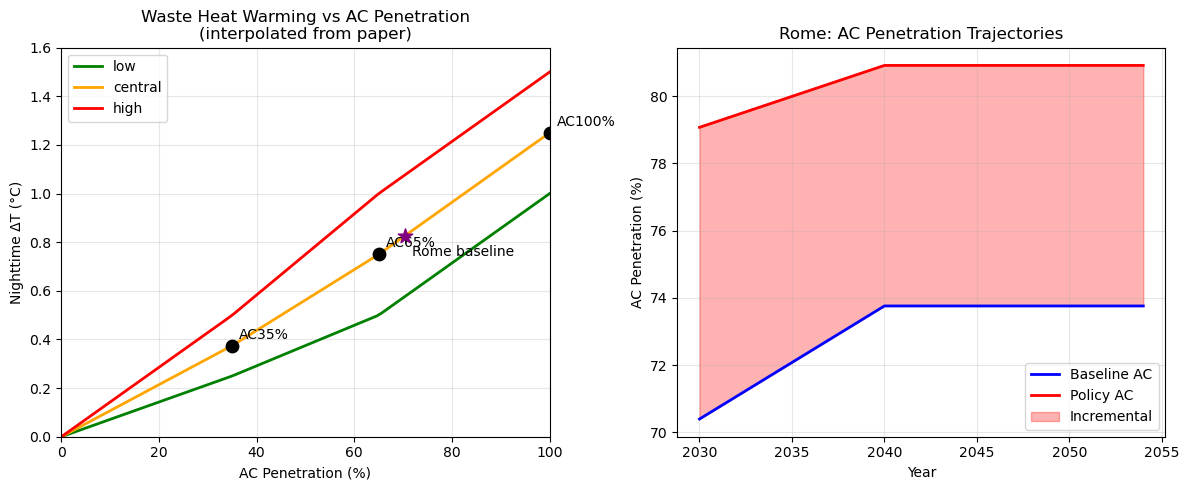

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_wasteheat_interpolation.png


In [16]:
import matplotlib.pyplot as plt

# plotting the waste heat curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: Nighttime change in T vs penetration
ax = axes[0]
pen_range = np.linspace(0, 1, 100)
for case, color in [("low", "green"), ("central", "orange"), ("high", "red")]:
    dT = dT_night_from_penetration(pen_range, case=case)
    ax.plot(pen_range * 100, dT, label=f"{case}", color=color, lw=2)

# marking paper's data points
for pen, vals in AC_WASTEHEAT_LUT.items():
    if pen > 0:
        ax.scatter([pen*100], [vals["central"]], color="black", s=80, zorder=5)
        ax.annotate(f"AC{int(pen*100)}%", (pen*100, vals["central"]), 
                   textcoords="offset points", xytext=(5,5))

# marking city's position (baseline start year)
dT_val = dT_night_from_penetration(pen_base_t[0], "central")
ax.scatter([pen_base_t[0]*100], [dT_val], color="purple", s=120, marker="*", zorder=6)
ax.annotate(f"{SLUG.title()} baseline", (pen_base_t[0]*100, dT_val), 
            textcoords="offset points", xytext=(5,-15))

ax.set_xlabel("AC Penetration (%)")
ax.set_ylabel("Nighttime ΔT (°C)")
ax.set_title("Waste Heat Warming vs AC Penetration\n(interpolated from paper)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.6)

# right: time series for city
ax = axes[1]
ax.plot(ELEC_YEARS, pen_base_t * 100, label="Baseline AC", color="blue", lw=2)
ax.plot(ELEC_YEARS, pen_pol_t * 100, label="Policy AC", color="red", lw=2)
ax.fill_between(ELEC_YEARS, pen_base_t * 100, pen_pol_t * 100, alpha=0.3, color="red", 
                label="Incremental")
ax.set_xlabel("Year")
ax.set_ylabel("AC Penetration (%)")
ax.set_title(f"{SLUG.title()}: AC Penetration Trajectories")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_wasteheat_interpolation.png", dpi=150)
plt.show()
print(f"Saved: {OUT / f'{SLUG}_wasteheat_interpolation.png'}")

**note**: this was just to reproduce more or less the figure of the paper.

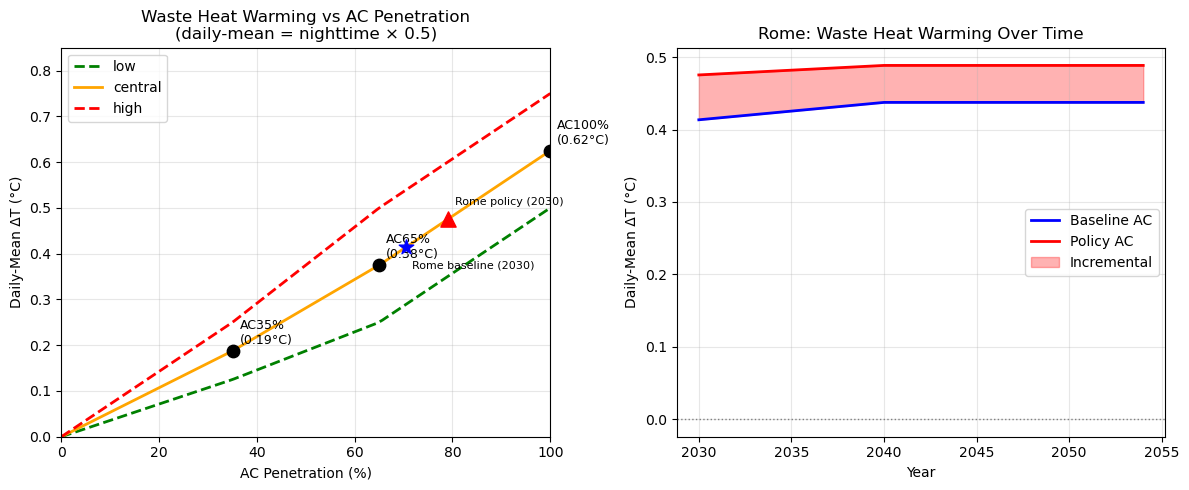

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_wasteheat_dailymean.png

AC penetration at anchor years:
  2030: baseline=70.4%, policy=79.1%, dT_dm_base=0.414°C, dT_dm_pol=0.476°C
  2040: baseline=73.8%, policy=80.9%, dT_dm_base=0.438°C, dT_dm_pol=0.489°C
  2050: baseline=73.8%, policy=80.9%, dT_dm_base=0.438°C, dT_dm_pol=0.489°C


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: Daily-mean change in T vs penetration (halved from nighttime)
ax = axes[0]
pen_range = np.linspace(0, 1, 100)

for case, color, ls in [("low", "green", "--"), ("central", "orange", "-"), ("high", "red", "--")]:
    dT_night = dT_night_from_penetration(pen_range, case=case)
    dT_daily = DAILYMEAN_FROM_NIGHT * dT_night  # HALVING
    ax.plot(pen_range * 100, dT_daily, label=f"{case}", color=color, lw=2, ls=ls)

# marking paper's data points (converted to daily-mean)
for pen, vals in AC_WASTEHEAT_LUT.items():
    if pen > 0:
        dT_dm = DAILYMEAN_FROM_NIGHT * vals["central"]
        ax.scatter([pen*100], [dT_dm], color="black", s=80, zorder=5)
        ax.annotate(f"AC{int(pen*100)}%\n({dT_dm:.2f}°C)", (pen*100, dT_dm), 
                   textcoords="offset points", xytext=(5,5), fontsize=9)

# marking city's baseline and policy positions
for label, pen_val, color, marker in [
    (f"{SLUG.title()} baseline (2030)", pen_base_t[0], "blue", "*"),
    (f"{SLUG.title()} policy (2030)", pen_pol_t[0], "red", "^"),
]:
    dT_dm = DAILYMEAN_FROM_NIGHT * dT_night_from_penetration(pen_val, "central")
    ax.scatter([pen_val*100], [dT_dm], color=color, s=120, marker=marker, zorder=6)
    ax.annotate(label, (pen_val*100, dT_dm), textcoords="offset points", 
                xytext=(5, -15 if "baseline" in label else 10), fontsize=8)

ax.set_xlabel("AC Penetration (%)")
ax.set_ylabel("Daily-Mean ΔT (°C)")
ax.set_title("Waste Heat Warming vs AC Penetration\n(daily-mean = nighttime × 0.5)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 0.85)

# right: Time series of daily-mean change in T
ax = axes[1]
ax.plot(ELEC_YEARS, dT_dm_vs_NoOut_base, label="Baseline AC", color="blue", lw=2)
ax.plot(ELEC_YEARS, dT_dm_vs_NoOut_policy, label="Policy AC", color="red", lw=2)
ax.fill_between(ELEC_YEARS, dT_dm_vs_NoOut_base, dT_dm_vs_NoOut_policy, 
                alpha=0.3, color="red", label="Incremental")
ax.axhline(0, color="gray", ls=":", lw=1)

ax.set_xlabel("Year")
ax.set_ylabel("Daily-Mean ΔT (°C)")
ax.set_title(f"{SLUG.title()}: Waste Heat Warming Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_wasteheat_dailymean.png", dpi=150)
plt.show()
print(f"Saved: {OUT / f'{SLUG}_wasteheat_dailymean.png'}")

# printing penetration at anchor years for verification
print("\nAC penetration at anchor years:")
for yr in [2030, 2040, 2050]:
    idx = np.where(ELEC_YEARS == yr)[0]
    if len(idx) > 0:
        i = idx[0]
        print(f"  {yr}: baseline={pen_base_t[i]:.1%}, policy={pen_pol_t[i]:.1%}, "
              f"dT_dm_base={dT_dm_vs_NoOut_base[i]:.3f}°C, dT_dm_pol={dT_dm_vs_NoOut_policy[i]:.3f}°C")

In [18]:
print("First 5 years of elec_eur_t:", elec_eur_t[:5])
print("Last 5 years of elec_eur_t:", elec_eur_t[-5:])

First 5 years of elec_eur_t: [79169241.80536377 78003412.78745282 76826613.31232321 75638953.39170742
 74440543.03733802]
Last 5 years of elec_eur_t: [68771672.0060873 68771672.0060873 68771672.0060873 68771672.0060873
 68771672.0060873]


In [19]:
# Report BOTH: absolute (vs NoOut) (LIKE IN PAPER) and incremental (policy - baseline) 
wasteheat_df = pd.DataFrame({
    "year": ELEC_YEARS,
    "dT_night_base_vs_NoOut": dT_night_vs_NoOut_base,
    "dT_night_policy_vs_NoOut": dT_night_vs_NoOut_policy,
    "dT_night_incremental": dT_night_incremental,
    "dT_dm_base_vs_NoOut": dT_dm_vs_NoOut_base,
    "dT_dm_policy_vs_NoOut": dT_dm_vs_NoOut_policy,
    "dT_dm_incremental": dT_dm_incremental,
})

# quick summary numbers 
rep = {
    "night_max_base": float(np.max(wasteheat_df["dT_night_base_vs_NoOut"])),
    "night_max_policy": float(np.max(wasteheat_df["dT_night_policy_vs_NoOut"])),
    "night_max_incremental": float(np.max(wasteheat_df["dT_night_incremental"])),
    "dm_max_base": float(np.max(wasteheat_df["dT_dm_base_vs_NoOut"])),
    "dm_max_policy": float(np.max(wasteheat_df["dT_dm_policy_vs_NoOut"])),
    "dm_max_incremental": float(np.max(wasteheat_df["dT_dm_incremental"])),
}
print("Waste-heat ΔT (°C) maxima over horizon:", {k: round(v, 4) for k, v in rep.items()})

# optional: save for appendix / figures
(TAB_DIR / f"{SLUG}_ac_wasteheat_timeseries.csv").write_text(wasteheat_df.to_csv(index=False))
print("Saved:", TAB_DIR / f"{SLUG}_ac_wasteheat_timeseries.csv")

Waste-heat ΔT (°C) maxima over horizon: {'night_max_base': 0.8752, 'night_max_policy': 0.9774, 'night_max_incremental': 0.124, 'dm_max_base': 0.4376, 'dm_max_policy': 0.4887, 'dm_max_incremental': 0.062}
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/tables/rome_ac_wasteheat_timeseries.csv


**Benefits and summary**

- Health benefits time series (avoided heat deaths)
  - Read annual avoided deaths outputs (trees, AC, both, and trees-on-top)
  - Interpolate to full horizon
  - Apply tree rollout + maturity factor (dynamic) vs “full from start” (static)

In [20]:
# Benefits and summary
import numpy as np
import pandas as pd
from pathlib import Path

HORIZON_YEARS = T
DISCOUNT_RATE = R
INT = Path(INT)

USE_SCALED_BENEFITS = False

def _nb6_path(stem: str) -> Path:
    return INT / (f"{stem}_scaled_{SLUG}.csv" if USE_SCALED_BENEFITS else f"{stem}_{SLUG}.csv")

def _read_overall(stem: str) -> pd.Series:
    p = _nb6_path(stem)
    if not p.exists():
        raise FileNotFoundError(f"Missing NB6 output: {p}")
    s = pd.read_csv(p, index_col="year")["overall"]
    s.index = s.index.astype(int)
    return s.sort_index()

def pv_of_stream(cashflows, r=DISCOUNT_RATE):
    yrs = np.arange(1, len(cashflows) + 1, dtype=float)
    return float(np.sum(np.asarray(cashflows, float) * (1 + r) ** (-yrs)))
    
def summarize_benefits(prefix, trees, ac, top, both, r=DISCOUNT_RATE):
    pv = {
        f"{prefix}_PV_trees": pv_of_stream(trees, r),
        f"{prefix}_PV_ac":   pv_of_stream(ac, r),
        f"{prefix}_PV_top":  pv_of_stream(top, r),
        f"{prefix}_PV_both": pv_of_stream(both, r),
    }
    cum = {
        f"{prefix}_CUM_trees": float(np.sum(trees)),
        f"{prefix}_CUM_ac":    float(np.sum(ac)),
        f"{prefix}_CUM_top":   float(np.sum(top)),
        f"{prefix}_CUM_both":  float(np.sum(both)),
    }
    return pv, cum
    
def interpolate_to_horizon(s: pd.Series, years: np.ndarray) -> np.ndarray:
    s = s.sort_index()
    known = s.index.to_numpy(int)
    vals = s.to_numpy(float)
    out = np.interp(years, known, vals)
    out[years <= known[0]] = vals[0]
    out[years >= known[-1]] = vals[-1]
    return out

avo_trees = _read_overall("annual_heat_deaths_avoided_trees_curr_AC")
avo_ac = _read_overall("annual_heat_deaths_avoided_AC_curr_AC")
avo_both = _read_overall("annual_heat_deaths_avoided_treesplusAC_curr_AC")

try:
    avo_trees_on_top = _read_overall("annual_heat_deaths_avoided_trees_on_top_AC_curr_AC")
except FileNotFoundError:
    avo_trees_on_top = (avo_both - avo_ac).rename("overall")

# these are:
# If the full trees intervention (full ΔGVI map) were already in place
# (and effectively delivering its modeled cooling),
# what deaths would it avoid in each climate year?”
print("Trees – avoided deaths per year:")
print(avo_trees, "\n")

print("AC policy – avoided deaths per year:")
print(avo_ac, "\n")

print("Both (trees+AC vs current AC) – avoided deaths per year:")
print(avo_both, "\n")

print("Trees on top of AC (NB6 file) – avoided deaths per year:")
print(avo_trees_on_top)

# Horizon construction
START_YEAR = int(min(avo_trees.index.min(), avo_ac.index.min(), avo_both.index.min(), avo_trees_on_top.index.min()))
YEARS = np.arange(START_YEAR, START_YEAR + HORIZON_YEARS, dtype=int)

# CONVERT TEMPERATURE PENALTY TO EXTRA HEAT DEATHS
# We use the marginal deaths per °C computed in NB5 (with +1°C perturbation)
# and multiply by the daily-mean temperature penalty.

# Extra deaths (year t) = marginal_deaths_per_C(t) × ΔT_dailymean(t)
m1_path = INT / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv"
# Load marginal deaths per °C (computed in NB5 by running hazard+1°C)
M1 = pd.read_csv(m1_path, index_col="year").sort_index()
M1.index = M1.index.astype(int)

# making sure we have a total column
if "total" not in M1.columns:
    M1["total"] = M1[["<15", "15-64", "65+"]].sum(axis=1)

marginal_total_perC_t = interpolate_to_horizon(M1["total"], YEARS)  # length T

# we use NB 5 (not 4, I did a mistake before taking the old baseline)
legacy = INT / f"marginal_heat_deaths_perC_{SLUG}.csv"
if legacy.exists():
    print("Legacy NB4 marginal exists but will be ignored:", legacy)

trees_full = interpolate_to_horizon(avo_trees, YEARS)
ac_full    = interpolate_to_horizon(avo_ac, YEARS)
both_full  = interpolate_to_horizon(avo_both, YEARS)
top_full   = interpolate_to_horizon(avo_trees_on_top, YEARS)

# Trees benefits: cohort rollout (25y) + maturity (12y) + optional "pre-grown" shift
def cohort_rollout_maturity_factor(T, ramp_years, plant_share=None, start_age_years=0):
    """ factor[t] = sum_i plant_share[i] * maturity(age=t-i), where:
        - maturity(age=0) is forced to 0 -> benefits start at t+1
        - maturity for age>=1 is shifted by start_age_years (pre-grown trees)
    """
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T  # linear rollout over T years
    ages = np.arange(T + 1, dtype=float)  # 0..T (need +1 so age=0 exists explicitly)
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # enforce: no benefits in planting year
    return np.convolve(plant_share, maturity)[:T]

trees_factor_dynamic = cohort_rollout_maturity_factor(
    T=HORIZON_YEARS, ramp_years=TREE_RAMP_YEARS, start_age_years=TREE_START_AGE_YEARS
)
trees_factor_static = np.ones(HORIZON_YEARS, dtype=float)

def compute_streams(trees_full, ac_full, both_full, top_full, trees_factor):
    trees = trees_full * trees_factor
    ac = ac_full
    top = top_full * trees_factor
    both = ac + top
    return trees, ac, top, both

trees_dyn, ac_dyn, top_dyn, both_dyn = compute_streams(
    trees_full, ac_full, both_full, top_full, trees_factor_dynamic
)
trees_sta, ac_sta, top_sta, both_sta = compute_streams(
    trees_full, ac_full, both_full, top_full, trees_factor_static
)

# GROSS (no-feedback) summary, before any penalties 
pv_dyn_gross, cum_dyn_gross = summarize_benefits(
    "DYN_GROSS", trees_dyn, ac_dyn, top_dyn, both_dyn
)
pv_sta_gross, cum_sta_gross = summarize_benefits(
    "STA_GROSS", trees_sta, ac_sta, top_sta, both_sta
)

# AC-driven warming penalty -> extra heat deaths (annual), unit-consistent 

# We already built dT_dailymean_t in the AC-costs cell (nighttime -> daily-mean-equivalent).
# Align change in T to the same years as benefits
dT_dm_inc_y = pd.Series(dT_dm_incremental, index=ELEC_YEARS).reindex(YEARS).to_numpy(float)
dT_dm_base_y = pd.Series(dT_dm_vs_NoOut_base, index=ELEC_YEARS).reindex(YEARS).to_numpy(float)
dT_dm_pol_y  = pd.Series(dT_dm_vs_NoOut_policy, index=ELEC_YEARS).reindex(YEARS).to_numpy(float)

# exposure factor (default 1.0 = full city exposed to warming)
AC_WASTEHEAT_EXPOSURE = 1.0

# computing incremental mortality penalty (extra deaths from policy's waste heat)
if USE_AC_FEEDBACK and DELTA_T_CASE != "off":
    dT_eff_inc_y = AC_WASTEHEAT_EXPOSURE * np.maximum(dT_dm_inc_y, 0.0)
    warming_penalty_t = marginal_total_perC_t * dT_eff_inc_y
else:
    # “no feedback” mode: keeping temperature penalty series for reporting,
    # but do NOT hit the benefits.
    dT_eff_inc_y = np.zeros_like(dT_dm_inc_y, dtype=float)
    warming_penalty_t = np.zeros_like(marginal_total_perC_t, dtype=float)

# for paper-style reporting we can still keep these absolute series vs NoOut:
dT_eff_base_y = AC_WASTEHEAT_EXPOSURE * np.maximum(dT_dm_base_y, 0.0)
dT_eff_pol_y  = AC_WASTEHEAT_EXPOSURE * np.maximum(dT_dm_pol_y, 0.0)

penalty_base_vs_NoOut_t   = marginal_total_perC_t * dT_eff_base_y
penalty_policy_vs_NoOut_t = marginal_total_perC_t * dT_eff_pol_y

print("Waste-heat mortality (extra heat deaths) over horizon:")
print("  baseline vs NoOut:", round(float(penalty_base_vs_NoOut_t.sum()), 3))
print("  policy   vs NoOut:", round(float(penalty_policy_vs_NoOut_t.sum()), 3))
print("  incremental (policy-baseline):", round(float(warming_penalty_t.sum()), 3))

CLIP_NET_AT_ZERO = False

# NET AC BENEFITS (subtracting the waste-heat externality)
# Trees are unaffected by AC waste heat (no penalty).
# AC-only and Both scenarios have the penalty subtracted.
def net_ac_stream(ac_stream):
    raw = ac_stream - warming_penalty_t
    return np.maximum(raw, 0.0) if CLIP_NET_AT_ZERO else raw
# trees don't cause waste heat, 
# so they keep their full benefit. Only AC benefits are reduced by the externality.

# Net streams (trees unaffected; AC and both penalized)
trees_dyn_net = trees_dyn  # No change
top_dyn_net   = top_dyn    # Reduced by waste-heat deaths
ac_dyn_net    = net_ac_stream(ac_dyn) # Trees-on-top unaffected
both_dyn_net  = top_dyn_net + ac_dyn_net # Combined

trees_sta_net = trees_sta
top_sta_net   = top_sta
ac_sta_net    = net_ac_stream(ac_sta)
both_sta_net  = top_sta_net + ac_sta_net

# NET (with-feedback) summary 
pv_dyn_net, cum_dyn_net = summarize_benefits(
    "DYN_NET", trees_dyn_net, ac_dyn_net, top_dyn_net, both_dyn_net
)
pv_sta_net, cum_sta_net = summarize_benefits(
    "STA_NET", trees_sta_net, ac_sta_net, top_sta_net, both_sta_net
)

# Diagnostic: does AC waste-heat cancel out tree gains? 
check = pd.DataFrame({
    "year": YEARS,
    "trees_on_top": top_dyn_net,
    "trees_only": trees_dyn_net,
    "ac_wasteheat_penalty": warming_penalty_t,
})
check["penalty_over_trees_on_top"] = check["ac_wasteheat_penalty"] / check["trees_on_top"].replace(0, np.nan)
check["penalty_over_trees_only"]   = check["ac_wasteheat_penalty"] / check["trees_only"].replace(0, np.nan)

print(check.head(10))
print(check[["trees_on_top","trees_only","ac_wasteheat_penalty"]].sum())

# sanity check
dbg = pd.DataFrame({
    "year": YEARS,
    "ac_gross": ac_dyn,
    "dT_dm_base_vs_NoOut": dT_dm_base_y,
    "dT_dm_policy_vs_NoOut": dT_dm_pol_y,
    "dT_dm_incremental": dT_dm_inc_y,
    "marg_deaths_perC": marginal_total_perC_t,
    "penalty_base_vs_NoOut": penalty_base_vs_NoOut_t,
    "penalty_policy_vs_NoOut": penalty_policy_vs_NoOut_t,
    "penalty_incremental": warming_penalty_t,
})

dbg["net_ac"] = ac_dyn_net
dbg["penalty_over_gross"] = dbg["penalty_incremental"] / dbg["ac_gross"].replace(0, np.nan)

print(dbg.head(8))
print("\nSums over horizon:")
print(dbg[["ac_gross", "penalty_base_vs_NoOut", "penalty_policy_vs_NoOut", "penalty_incremental", "net_ac"]].sum())

pv_dyn, cum_dyn = summarize_benefits("DYN", trees_dyn_net, ac_dyn_net, top_dyn_net, both_dyn_net)
pv_sta, cum_sta = summarize_benefits("STA", trees_sta_net, ac_sta_net, top_sta_net, both_sta_net)

print("Cumulative avoided deaths (25y, undiscounted):")
print(
    f" DYNAMIC — Trees: {cum_dyn['DYN_CUM_trees']:.2f} | AC: {cum_dyn['DYN_CUM_ac']:.2f} | "
    f"Trees on top: {cum_dyn['DYN_CUM_top']:.2f} | Both: {cum_dyn['DYN_CUM_both']:.2f}"
)
print(
    f" STATIC — Trees: {cum_sta['STA_CUM_trees']:.2f} | AC: {cum_sta['STA_CUM_ac']:.2f} | "
    f"Trees on top: {cum_sta['STA_CUM_top']:.2f} | Both: {cum_sta['STA_CUM_both']:.2f}"
)
print("\nNote: 'STATIC' assumes full policy effect from the first year of the horizon.")
print(" 'DYNAMIC' assumes gradual rollout + tree maturity, so early benefits are smaller.")

Trees – avoided deaths per year:
year
2030    7.625836
2040    9.163901
2050    9.225842
Name: overall, dtype: float64 

AC policy – avoided deaths per year:
year
2030    37.238405
2040    39.370713
2050    38.799595
Name: overall, dtype: float64 

Both (trees+AC vs current AC) – avoided deaths per year:
year
2030    44.092701
2040    47.728491
2050    47.211566
Name: overall, dtype: float64 

Trees on top of AC (NB6 file) – avoided deaths per year:
year
2030    6.854295
2040    8.357778
2050    8.411971
Name: overall, dtype: float64
Legacy NB4 marginal exists but will be ignored: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/marginal_heat_deaths_perC_rome.csv
Waste-heat mortality (extra heat deaths) over horizon:
  baseline vs NoOut: 3410.172
  policy   vs NoOut: 3832.372
  incremental (policy-baseline): 422.2
   year  trees_on_top  trees_only  ac_wasteheat_penalty  \
0  2030      0.000000    0.000000             19.470332   
1  2031      0.140093  

**Outputs variables**:
- dT_night_vs_NoOut_base: Baseline nighttime warming (vs. no waste heat), in °C
- dT_night_vs_NoOut_policy: Policy nighttime warming (vs. no waste heat), in °C
- dT_night_incremental: Incremental nighttime warming (policy − baseline), in °C
- dT_dm_incremental, Incremental daily-mean warming, in °C
- ac_gross: avoided deaths over 25 y of AC without the waste heat, net_ac: avoided deaths over 25 y of AC with waste heat. 
- warming_penalty_t, Extra deaths from waste-heat warming, deaths/year
- ac_dyn_net, Net AC benefits after subtracting penalty, deaths avoided/year

**Interpretation**:
- Need to UPDATE my interpretation (was still the old one) 

**Comparison AC feedback and trees benefits**

If AC policy increases outdoor temperatures via waste heat, does that warming cancel out the cooling benefit from trees? **intuition**: Trees cool the outdoor environment (ΔT negative), while AC waste heat warms it (ΔT positive). If the warming exceeds the cooling, trees would appear useless in the "both policies" scenario.

**TO UPDATE** 

- Trees provide XXX cooling (implied from X avoided deaths / X deaths per °C)
AC waste heat adds XXX°C warming (incremental, policy minus baseline)
Net effect: Trees still cool, just slightly less than they would without AC expansion

- The waste-heat penalty erases about XXX% of tree benefits (higher in PV terms because the penalty is front-loaded in early years when trees are still ramping up). But XXX% of tree benefits remain.

In [21]:
import numpy as np
import pandas as pd

eps = 1e-9

# before we did: warming_penalty_t = marginal_total_perC_t * dT_eff_inc_y  
# This converts the incremental temperature increase (°C) 
# into extra deaths using the marginal deaths-per-°C from NB5. 
# The units are consistent: (deaths/°C) × (°C) = deaths.
# Tree benefit (avoided deaths from GVI cooling)  
trees_top = np.asarray(top_dyn_net, float)         # trees-on-top (dynamic rollout+maturity)
pen = np.asarray(warming_penalty_t, float)         # incremental waste-heat deaths (policy-baseline)

# A) original diagnostics
wipe_year = pen >= trees_top - eps

cum_share = pen.sum() / max(trees_top.sum(), eps)
pv_share  = pv_of_stream(pen, R) / max(pv_of_stream(trees_top, R), eps)

trees_top_net_of_feedback = trees_top - pen
cum_net = trees_top_net_of_feedback.sum()
pv_net  = pv_of_stream(trees_top_net_of_feedback, R)

print("Years where penalty >= trees-on-top:", YEARS[wipe_year])
print("Cumulative share of trees-on-top erased:", cum_share)
print("PV share of trees-on-top erased:", pv_share)
print("Cumulative net trees-on-top after feedback:", cum_net)
print("PV net trees-on-top after feedback:", pv_net)

# B) More meaningful: ignoring years when trees around 0 (ramp)
min_tree = 1.0  # deaths/year threshold
mask = trees_top >= min_tree

wipe_year_masked = mask & (pen >= trees_top - eps)

cum_share_masked = pen[mask].sum() / max(trees_top[mask].sum(), eps)
pv_share_masked  = pv_of_stream(pen[mask], R) / max(pv_of_stream(trees_top[mask], R), eps)

print("\n[Masked wipe-out check]")
print(f"Threshold: trees_on_top >= {min_tree} death/yr")
print("Wipe years (masked):", YEARS[wipe_year_masked])
print("Cumulative share erased (masked):", cum_share_masked)
print("PV share erased (masked):", pv_share_masked)

# C) Temperature-equivalent comparison (does warming cancel cooling?)
# Implied cooling (°C) that would produce trees-on-top avoided deaths under the same marginal slope
marg = np.asarray(marginal_total_perC_t, float)
dT_equiv_trees_top_C = np.where(marg > 0, trees_top / marg, np.nan)
# In °C terms, how does waste-heat warming compare to tree cooling? 
# A ratio > 1 would mean waste heat exceeds tree cooling. 
# result shows no such years (after masking).

# Waste-heat incremental warming (°C) already computed earlier (daily-mean-equivalent, exposure-weighted)
dT_wasteheat_inc_C = np.asarray(dT_eff_inc_y, float)

# Ratio only where tree-equivalent cooling is positive & trees are non-trivial (optional)
ratio = np.full_like(dT_equiv_trees_top_C, np.nan, dtype=float)
ratio_mask = np.isfinite(dT_equiv_trees_top_C) & (dT_equiv_trees_top_C > 0) & mask
ratio[ratio_mask] = dT_wasteheat_inc_C[ratio_mask] / dT_equiv_trees_top_C[ratio_mask]

comp = pd.DataFrame({
    "year": YEARS,
    "trees_on_top_deaths": trees_top,
    "wasteheat_penalty_deaths": pen,
    "net_trees_on_top_deaths": trees_top - pen,
    "dT_equiv_trees_top_C": dT_equiv_trees_top_C,
    "dT_wasteheat_inc_C": dT_wasteheat_inc_C,
    "T_ratio_wasteheat_over_trees": ratio,
})

finite_ratio = comp["T_ratio_wasteheat_over_trees"].to_numpy()
finite_ratio = finite_ratio[np.isfinite(finite_ratio)]

print("\n[Temperature-equivalent check]")
print("Years with ratio > 1 (wasteheat > trees cooling):",
      comp.loc[comp["T_ratio_wasteheat_over_trees"] > 1, "year"].to_numpy())
print("Median ratio (finite, masked years):",
      float(np.median(finite_ratio)) if finite_ratio.size else np.nan)

display(comp.head(12))
comp.to_csv(TAB_DIR / f"{SLUG}_trees_vs_wasteheat_comparison.csv", index=False)
print("Saved:", TAB_DIR / f"{SLUG}_trees_vs_wasteheat_comparison.csv")

Years where penalty >= trees-on-top: [2030 2031 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043
 2044 2045 2046 2047 2048 2049 2050 2051 2052 2053 2054]
Cumulative share of trees-on-top erased: 4.85677341742553
PV share of trees-on-top erased: 5.744492757393685
Cumulative net trees-on-top after feedback: -335.2695157303273
PV net trees-on-top after feedback: -246.28694003032106

[Masked wipe-out check]
Threshold: trees_on_top >= 1.0 death/yr
Wipe years (masked): [2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048
 2049 2050 2051 2052 2053 2054]
Cumulative share erased (masked): 3.846239909807906
PV share erased (masked): 4.199507552171989

[Temperature-equivalent check]
Years with ratio > 1 (wasteheat > trees cooling): [2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045 2046 2047 2048
 2049 2050 2051 2052 2053 2054]
Median ratio (finite, masked years): 3.7902025920775735


,year,trees_on_top_deaths,wasteheat_penalty_deaths,net_trees_on_top_deaths,dT_equiv_trees_top_C,dT_wasteheat_inc_C,T_ratio_wasteheat_over_trees
0,2030,0.000000,19.470332,-19.470332,0.000000,0.061993,NaN
1,2031,0.140093,19.178084,-19.037991,0.000445,0.060905,NaN
2,2032,0.310050,18.884077,-18.574027,0.000982,0.059818,NaN
3,2033,0.511374,18.588311,-18.076937,0.001616,0.058731,NaN
4,2034,0.745569,18.290787,-17.545218,0.002350,0.057643,NaN
5,2035,1.014138,17.991504,-16.977365,0.003188,0.056556,17.740682
6,2036,1.318585,17.690462,-16.371877,0.004134,0.055469,13.416243
7,2037,1.660414,17.387662,-15.727248,0.005193,0.054381,10.471884
8,2038,2.014270,17.083103,-15.068833,0.006284,0.053294,8.481038
9,2039,2.380155,16.776786,-14.396631,0.007407,0.052207,7.048612


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/tables/rome_trees_vs_wasteheat_comparison.csv


"Wipe-Out Years" Issue: artifact of tree maturity timing. In years 2030-2034, trees are barely planted (rollout just starting), so their benefit is near zero. Meanwhile, the waste-heat penalty exists immediately. 

=> AC waste heat erodes XXX of the PV value of trees-on-top, but doesn’t eliminate it

In [22]:
import numpy as np
import pandas as pd

eps = 1e-9

# using already-built series 
pen = np.asarray(warming_penalty_t, float)     # incremental extra deaths from waste heat (policy - baseline)
trees_only = np.asarray(trees_dyn_net, float)  # trees only (dynamic rollout+maturity)
trees_top  = np.asarray(top_dyn_net, float)    # trees on top of AC policy (dynamic rollout+maturity)

# helper
def _pv(x): 
    return pv_of_stream(np.asarray(x, float), R)

def _shares(benefit, name, min_benefit=1.0):
    benefit = np.asarray(benefit, float)
    mask = benefit >= min_benefit

    out = {
        "compare_to": name,
        "min_benefit_threshold": float(min_benefit),
        "wipe_years_unmasked": YEARS[pen >= benefit - eps].tolist(),
        "wipe_years_masked": YEARS[(mask) & (pen >= benefit - eps)].tolist(),
        "cum_benefit": float(benefit.sum()),
        "cum_penalty": float(pen.sum()),
        "cum_share_erased_unmasked": float(pen.sum() / max(benefit.sum(), eps)),
        "pv_benefit": float(_pv(benefit)),
        "pv_penalty": float(_pv(pen)),
        "pv_share_erased_unmasked": float(_pv(pen) / max(_pv(benefit), eps)),
        "cum_share_erased_masked": float(pen[mask].sum() / max(benefit[mask].sum(), eps)) if mask.any() else np.nan,
        "pv_share_erased_masked": float(_pv(pen[mask]) / max(_pv(benefit[mask]), eps)) if mask.any() else np.nan,
        "cum_net_after_penalty": float((benefit - pen).sum()),
        "pv_net_after_penalty": float(_pv(benefit - pen)),
    }
    return out

rows = [
    _shares(trees_only, "trees_only (vs current AC)"),
    _shares(trees_top,  "trees_on_top (incremental on AC policy)"),
]

summary_penalty_vs_trees = pd.DataFrame(rows)
display(summary_penalty_vs_trees)

out_csv = TAB_DIR / f"{SLUG}_penalty_vs_trees_summary.csv"
summary_penalty_vs_trees.to_csv(out_csv, index=False)
print("Saved:", out_csv)

,compare_to,min_benefit_threshold,wipe_years_unmasked,wipe_years_masked,cum_benefit,cum_penalty,cum_share_erased_unmasked,pv_benefit,pv_penalty,pv_share_erased_unmasked,cum_share_erased_masked,pv_share_erased_masked,cum_net_after_penalty,pv_net_after_penalty
0,trees_only (vs current AC),1.0,"[2030, 2031, 2032, 2033, 2034, 2035, 2036, 203...","[2035, 2036, 2037, 2038, 2039, 2040, 2041, 204...",95.379855,422.199568,4.426507,56.966267,298.197008,5.234624,3.506119,3.827769,-326.819714,-241.230741
1,trees_on_top (incremental on AC policy),1.0,"[2030, 2031, 2032, 2033, 2034, 2035, 2036, 203...","[2035, 2036, 2037, 2038, 2039, 2040, 2041, 204...",86.930053,422.199568,4.856773,51.910068,298.197008,5.744493,3.846240,4.199508,-335.269516,-246.286940


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/tables/rome_penalty_vs_trees_summary.csv


- Versus trees-only, the incremental waste-heat penalty is:
    - XXX% of cumulative tree benefit (XXX)
    - XXX% of PV tree benefit (XXX).

- Versus trees-on-top, it’s:
    - XXX% of cumulative (XXX/XXX)
    - XXX% of PV (XXX)

Bottom line: under current calibration, waste heat reduces the apparent benefit of trees (especially in PV terms), but does not fully null it; net remains positive.

In [23]:
print([v for v in dir() if 'baseline' in v.lower() or 'total' in v.lower()])

# loading deaths CSVs from previous notebooks:
baseline_deaths_path = INT / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv"
if baseline_deaths_path.exists():
    baseline_df = pd.read_csv(baseline_deaths_path)
    baseline_total = interpolate_to_horizon(baseline_df.set_index("year")["total"], YEARS)
else:
    # or: using the "generic" deaths (no AC protection)
    generic_path = INT / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv"
    if Path(generic_path).exists():
        df_avo = pd.read_csv(generic_path)
    print("Could not find baseline deaths file")

['EAC_ac_total', 'EAC_total_annuity', 'PV_ac_total', 'PV_total', 'PV_trees_total', 'known_totals', 'marginal_total_perC_t', 'pop_2030_total', 'pop_muni_total_t', 'pop_total_for_year']


In [24]:
# World A: Baseline AC, no trees
# World B: Baseline AC + trees
# World C: Policy AC + trees ("both" scenario)

# deaths in each world (using existing variables)
deaths_A = baseline_total  # no intervention
deaths_B = baseline_total - trees_dyn_net  # trees only (at baseline AC)
deaths_C = baseline_total - both_dyn_net   # trees + AC policy

print("SCENARIO COMPARISON (cumulative deaths)")
print(f"A: Baseline AC, no trees:    {deaths_A.sum():.0f}")
print(f"B: Baseline AC + trees:      {deaths_B.sum():.0f}  (trees save {(deaths_A - deaths_B).sum():.0f})")
print(f"C: Policy AC + trees:        {deaths_C.sum():.0f}  (saves {(deaths_A - deaths_C).sum():.0f})")

# Key question: does C beat B?
print(f"\nDoes AC policy help beyond trees? {(deaths_B - deaths_C).sum():.0f} additional deaths avoided")

SCENARIO COMPARISON (cumulative deaths)
A: Baseline AC, no trees:    17018
B: Baseline AC + trees:      16922  (trees save 95)
C: Policy AC + trees:        16386  (saves 632)

Does AC policy help beyond trees? 536 additional deaths avoided


In [25]:
# Computing maturity_factor_t
# This is the tree growth ramp we defined earlier
# Typically: linear ramp from 0 to 1 over TREE_RAMP_YEARS

def tree_maturity_factor(years, start_year=2030, ramp_years=12, start_age=5):
    """
    Returns array of maturity factors (0 to 1) for each year.
    start_age: trees start at age 5 (pre-grown), so partial credit initially
    """
    factors = np.zeros(len(years), dtype=float)
    for i, y in enumerate(years):
        years_since_start = y - start_year
        if years_since_start < 0:
            factors[i] = 0.0
        else:
            # Linear ramp: age goes from start_age to (start_age + ramp_years)
            effective_age = start_age + years_since_start
            maturity_age = start_age + ramp_years
            factors[i] = min(effective_age / maturity_age, 1.0)
    return factors

maturity_factor_t = tree_maturity_factor(YEARS, start_year=2030, 
                                          ramp_years=TREE_RAMP_YEARS, 
                                          start_age=TREE_START_AGE_YEARS)
print("Maturity factors:", maturity_factor_t[:10], "...", maturity_factor_t[-3:])

Maturity factors: [0.29411765 0.35294118 0.41176471 0.47058824 0.52941176 0.58823529
 0.64705882 0.70588235 0.76470588 0.82352941] ... [1. 1. 1.]


In [26]:
# defining years_mature (years after tree ramp-up completes)
years_mature = YEARS >= (2030 + TREE_RAMP_YEARS)
print(f"Mature years: {YEARS[years_mature][0]} to {YEARS[years_mature][-1]}")

# defining trees_alone (from scenario comparison)
# This requires deaths_A, deaths_B which need baseline_total
# If baseline_total not defined, computing it:
if 'baseline_total' not in dir():
    baseline_deaths_path = INT / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv"
    if baseline_deaths_path.exists():
        baseline_df = pd.read_csv(baseline_deaths_path)
        baseline_total = interpolate_to_horizon(baseline_df.set_index("year")["total"], YEARS)
    else:
        print(f"WARNING: {baseline_deaths_path} not found")

# computing scenario deaths
deaths_A = baseline_total
deaths_B = baseline_total - trees_dyn_net
deaths_C = baseline_total - both_dyn_net

# defining trees_alone and both
trees_alone = (deaths_A - deaths_B).sum()
both = (deaths_A - deaths_C).sum()

print(f"trees_alone = {trees_alone:.0f} deaths avoided")
print(f"both = {both:.0f} deaths avoided")

Mature years: 2042 to 2054
trees_alone = 95 deaths avoided
both = 632 deaths avoided


In [27]:
# SECTION: AC WASTE HEAT vs TREE COOLING, DIRECT change in T COMPARISON

# loading tree cooling from NB6
veg_aux = np.load(INT / f"{SLUG}_veg_aux_arrays.npz")
dT_month_ref = veg_aux["dT_month_ref"]  # (12, H, W)
# taking 2050 pop grid for the current exposure scenario (same scen_key as above)
pop_2050_npz_path = expo_manifest["scenarios"][scen_key]["2050"]["pop_npz"]
pop_2050 = np.load(pop_2050_npz_path)["pop"].astype("float32")

# computing pop-weighted summer tree cooling
summer_idx = [5, 6, 7]  # Jun, Jul, Aug (0-indexed)
w = np.where(np.isfinite(pop_2050) & (pop_2050 > 0), pop_2050, 0)
pw_dT_summer = np.mean([np.nansum(dT_month_ref[m] * w) / w.sum() for m in summer_idx])

# applying tree maturity ramp (same as benefits)
tree_maturity = maturity_factor_t  # from existing code
dT_trees_t = pw_dT_summer * tree_maturity  # ramps up with tree growth

# comparing to TOTAL AC waste heat (baseline scenario)
dT_waste_total_t = dT_eff_base_y  # total waste heat under baseline AC

# net temperature effect over time
dT_net_t = dT_trees_t + dT_waste_total_t  # negative = net cooling

# Summary table
comp_direct = pd.DataFrame({
    "year": YEARS,
    "dT_trees_C": dT_trees_t,
    "dT_waste_total_C": dT_waste_total_t,
    "dT_net_C": dT_net_t,
    "trees_dominate": dT_net_t < 0,
})

print("\n=== DIRECT TEMPERATURE COMPARISON ===")
print(f"At maturity (mean over {YEARS[years_mature][0]}+):")
print(f"  Tree cooling:      {dT_trees_t[years_mature].mean():.4f}°C")
print(f"  AC waste heat:    +{dT_waste_total_t[years_mature].mean():.4f}°C")
print(f"  Net effect:        {dT_net_t[years_mature].mean():.4f}°C")
print(f"  Trees win: {(dT_net_t[years_mature] < 0).all()}")

comp_direct.to_csv(TAB_DIR / f"{SLUG}_dT_trees_vs_wasteheat_direct.csv", index=False)


=== DIRECT TEMPERATURE COMPARISON ===
At maturity (mean over 2042+):
  Tree cooling:      -0.0313°C
  AC waste heat:    +0.4376°C
  Net effect:        0.4063°C
  Trees win: False


In [28]:
# SECTION: AC WASTE HEAT vs TREE COOLING — POLICY COMPARISON

print("=" * 65)
print("QUESTION: Does AC waste heat nullify tree cooling benefits?")
print("=" * 65)

# Scenario comparison 
print("\n[1] SCENARIO COMPARISON (cumulative deaths, 2030-2050)")
print(f"    A: Baseline AC, no trees:  {deaths_A.sum():,.0f}")
print(f"    B: Baseline AC + trees:    {deaths_B.sum():,.0f}  (trees save {trees_alone:.0f})")
print(f"    C: Policy AC + trees:      {deaths_C.sum():,.0f}  (both save {both:.0f})")

# Waste heat erosion 
print("\n[2] WASTE HEAT EROSION OF TREE BENEFITS")
print(f"    Tree-on-top benefit (cumulative):    {trees_top.sum():.1f} deaths avoided")
print(f"    AC waste heat penalty (cumulative):  {pen.sum():.1f} extra deaths")
print(f"    Erosion:                             {100*pen.sum()/trees_top.sum():.1f}%")

# At maturity 
print("\n[3] AT MATURITY (2042+)")
print(f"    Tree benefit:   {trees_top[years_mature].mean():.2f} deaths/yr avoided")
print(f"    AC penalty:     {pen[years_mature].mean():.2f} deaths/yr (→ 0 as baseline catches up)")

# Conclusion
print("\n" + "=" * 65)
print("CONCLUSION: AC waste heat does nullify tree benefits.")
print(f"  • Trees save {trees_alone:.0f} deaths (with or without AC policy)")
print(f"  • Waste heat erodes ~{100*pen.sum()/trees_top.sum():.0f}% of tree-on-top benefit")
print(f"  • But AC policy adds {both - trees_alone:.0f} more avoided deaths")
print(f"  • Net effect: TREES ON TOP OF AC IS NOT BENEFICIAL")
print("=" * 65)

QUESTION: Does AC waste heat nullify tree cooling benefits?

[1] SCENARIO COMPARISON (cumulative deaths, 2030-2050)
    A: Baseline AC, no trees:  17,018
    B: Baseline AC + trees:    16,922  (trees save 95)
    C: Policy AC + trees:      16,386  (both save 632)

[2] WASTE HEAT EROSION OF TREE BENEFITS
    Tree-on-top benefit (cumulative):    86.9 deaths avoided
    AC waste heat penalty (cumulative):  422.2 extra deaths
    Erosion:                             485.7%

[3] AT MATURITY (2042+)
    Tree benefit:   5.46 deaths/yr avoided
    AC penalty:     16.00 deaths/yr (→ 0 as baseline catches up)

CONCLUSION: AC waste heat does nullify tree benefits.
  • Trees save 95 deaths (with or without AC policy)
  • Waste heat erodes ~486% of tree-on-top benefit
  • But AC policy adds 536 more avoided deaths
  • Net effect: TREES ON TOP OF AC IS NOT BENEFICIAL


- Baseline mortality and percentage reductions
- 
We now read the baseline heat-attributable deaths with current AC (no new policy) from CLIMADA and:
    - compute total baseline deaths per year (summing over age classes)
    - align avoided deaths for trees, AC, and both to these baseline years
    - compute percentage reductions in baseline deaths:
      * trees_pct = % reduction with trees only
      * ac_pct    = % reduction with AC only
      * both_pct  = % reduction with both policies
      * trees_on_top_pct = extra % reduction from adding trees on top of AC

In [29]:
# building a clean "tree cost pack" for base vs 5x O&M (same timing convention)
def pack_tree_costs(PV_capex, PV_om, AF, TREES_CAPEX_T0, R, T):
    PV_total = PV_capex + PV_om
    return {
        "PV_capex": PV_capex,
        "PV_om": PV_om,
        "PV_total": PV_total,
        "EAC_capex_annuity": PV_capex / AF,
        "EAC_om_annuity": PV_om / AF,
        "EAC_total_annuity": PV_total / AF,
        # paper-style: capex-only shortcut, unchanged by O&M scenario
        "EAC_capex_paper": (TREES_CAPEX_T0 / ((1 + R) ** T)) / T,
    }

trees_cost_base = pack_tree_costs(PV_trees_capex, PV_trees_om, AF, TREES_CAPEX_T0, R, T)
trees_cost_5x = pack_tree_costs(PV_trees_capex, PV_om_5x, AF, TREES_CAPEX_T0, R, T)

In [30]:
# Summary table builder that takes a tree-cost scenario explicitly
def safe_ratio(c, b):
    return float(c / b) if (b is not None and b > 1e-9) else np.inf

def build_summary(label, cost_scenario, trees_cost, CUM_trees, CUM_ac, CUM_both, CUM_top):
    return pd.DataFrame([
        {
            "Benefit_timing": label,
            "Cost_scenario": cost_scenario,
            "Policy": "Trees only (vs current AC)",
            "PV_cost_eur": trees_cost["PV_total"],
            "avoided_deaths_cum": CUM_trees,
            "Cost_per_avoided_death_eur": safe_ratio(trees_cost["PV_total"], CUM_trees),
            "EAC_capex_annuity_eur_per_yr": trees_cost["EAC_capex_annuity"],
            "EAC_om_annuity_eur_per_yr": trees_cost["EAC_om_annuity"],
            "EAC_total_annuity_eur_per_yr": trees_cost["EAC_total_annuity"],
            "EAC_capex_paper_eur_per_yr": trees_cost["EAC_capex_paper"],
            "added_AC_users": 0.0,
        },
        {
            "Benefit_timing": label,
            "Cost_scenario": cost_scenario,
            "Policy": "AC only (vs current AC)",
            "PV_cost_eur": PV_ac_total,
            "avoided_deaths_cum": CUM_ac,
            "Cost_per_avoided_death_eur": safe_ratio(PV_ac_total, CUM_ac),
            "EAC_capex_annuity_eur_per_yr": 0.0,
            "EAC_om_annuity_eur_per_yr": 0.0,
            "EAC_total_annuity_eur_per_yr": EAC_ac_total,
            "EAC_capex_paper_eur_per_yr": np.nan,
            "added_AC_users": added_users_final,
        },
        {
            "Benefit_timing": label,
            "Cost_scenario": cost_scenario,
            "Policy": "Both (trees+AC vs current AC)",
            "PV_cost_eur": trees_cost["PV_total"] + PV_ac_total,
            "avoided_deaths_cum": CUM_both,
            "Cost_per_avoided_death_eur": safe_ratio(trees_cost["PV_total"] + PV_ac_total, CUM_both),
            "EAC_capex_annuity_eur_per_yr": trees_cost["EAC_capex_annuity"],
            "EAC_om_annuity_eur_per_yr": trees_cost["EAC_om_annuity"],
            "EAC_total_annuity_eur_per_yr": trees_cost["EAC_total_annuity"] + EAC_ac_total,
            "EAC_capex_paper_eur_per_yr": trees_cost["EAC_capex_paper"],
            "added_AC_users": added_users_final,
        },
        {
            "Benefit_timing": label,
            "Cost_scenario": cost_scenario,
            "Policy": "Trees (incremental, on top of AC policy)",
            "PV_cost_eur": trees_cost["PV_total"],
            "avoided_deaths_cum": CUM_top,
            "Cost_per_avoided_death_eur": safe_ratio(trees_cost["PV_total"], CUM_top),
            "EAC_capex_annuity_eur_per_yr": trees_cost["EAC_capex_annuity"],
            "EAC_om_annuity_eur_per_yr": trees_cost["EAC_om_annuity"],
            "EAC_total_annuity_eur_per_yr": trees_cost["EAC_total_annuity"],
            "EAC_capex_paper_eur_per_yr": trees_cost["EAC_capex_paper"],
            "added_AC_users": 0.0,
        },
    ])

# building base + sensitivity summaries for BOTH benefit-timing conventions
if "trees_cost_base" not in globals():
    trees_cost_base = pack_tree_costs(PV_trees_capex, PV_trees_om, AF, TREES_CAPEX_T0, R, T)
if "trees_cost_5x" not in globals():
    trees_cost_5x = pack_tree_costs(PV_trees_capex, PV_om_5x, AF, TREES_CAPEX_T0, R, T)

# ==== DYNAMIC, Base O&M ====
summary_dynamic_base_gross = build_summary(
    "Dynamic rollout + tree maturity (AC feedback OFF)",
    "Base O&M",
    trees_cost_base,
    cum_dyn_gross["DYN_GROSS_CUM_trees"],
    cum_dyn_gross["DYN_GROSS_CUM_ac"],
    cum_dyn_gross["DYN_GROSS_CUM_both"],
    cum_dyn_gross["DYN_GROSS_CUM_top"],
)

summary_dynamic_base_net = build_summary(
    "Dynamic rollout + tree maturity (AC feedback ON)",
    "Base O&M",
    trees_cost_base,
    cum_dyn_net["DYN_NET_CUM_trees"],
    cum_dyn_net["DYN_NET_CUM_ac"],
    cum_dyn_net["DYN_NET_CUM_both"],
    cum_dyn_net["DYN_NET_CUM_top"],
)

# ==== DYNAMIC, 5× O&M ====
summary_dynamic_5x_gross = build_summary(
    "Dynamic rollout + tree maturity (AC feedback OFF)",
    "O&M PV = 5× CAPEX PV",
    trees_cost_5x,
    cum_dyn_gross["DYN_GROSS_CUM_trees"],
    cum_dyn_gross["DYN_GROSS_CUM_ac"],
    cum_dyn_gross["DYN_GROSS_CUM_both"],
    cum_dyn_gross["DYN_GROSS_CUM_top"],
)

summary_dynamic_5x_net = build_summary(
    "Dynamic rollout + tree maturity (AC feedback ON)",
    "O&M PV = 5× CAPEX PV",
    trees_cost_5x,
    cum_dyn_net["DYN_NET_CUM_trees"],
    cum_dyn_net["DYN_NET_CUM_ac"],
    cum_dyn_net["DYN_NET_CUM_both"],
    cum_dyn_net["DYN_NET_CUM_top"],
)

# ==== STATIC, Base O&M ====
summary_static_base_gross = build_summary(
    "Static (full effect from start) (AC feedback OFF)",
    "Base O&M",
    trees_cost_base,
    cum_sta_gross["STA_GROSS_CUM_trees"],
    cum_sta_gross["STA_GROSS_CUM_ac"],
    cum_sta_gross["STA_GROSS_CUM_both"],
    cum_sta_gross["STA_GROSS_CUM_top"],
)

summary_static_base_net = build_summary(
    "Static (full effect from start) (AC feedback ON)",
    "Base O&M",
    trees_cost_base,
    cum_sta_net["STA_NET_CUM_trees"],
    cum_sta_net["STA_NET_CUM_ac"],
    cum_sta_net["STA_NET_CUM_both"],
    cum_sta_net["STA_NET_CUM_top"],
)

# ==== STATIC, 5× O&M ====
summary_static_5x_gross = build_summary(
    "Static (full effect from start) (AC feedback OFF)",
    "O&M PV = 5× CAPEX PV",
    trees_cost_5x,
    cum_sta_gross["STA_GROSS_CUM_trees"],
    cum_sta_gross["STA_GROSS_CUM_ac"],
    cum_sta_gross["STA_GROSS_CUM_both"],
    cum_sta_gross["STA_GROSS_CUM_top"],
)

summary_static_5x_net = build_summary(
    "Static (full effect from start) (AC feedback ON)",
    "O&M PV = 5× CAPEX PV",
    trees_cost_5x,
    cum_sta_net["STA_NET_CUM_trees"],
    cum_sta_net["STA_NET_CUM_ac"],
    cum_sta_net["STA_NET_CUM_both"],
    cum_sta_net["STA_NET_CUM_top"],
)

summary_all = pd.concat(
    [
        summary_dynamic_base_gross,
        summary_dynamic_base_net,
        summary_dynamic_5x_gross,
        summary_dynamic_5x_net,
        summary_static_base_gross,
        summary_static_base_net,
        summary_static_5x_gross,
        summary_static_5x_net,
    ],
    ignore_index=True,
).round(2)

summary_all

def run_tree_age_case(tree_start_age_years: int):
    # TREE COSTS (capex unchanged + O&M depends on start age)
    PV_trees_om_case, _ = npv_om_cohorts_scaled(
        DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
        ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS,
        start_age_years=tree_start_age_years,
    )
    trees_cost_case = pack_tree_costs(PV_trees_capex, PV_trees_om_case, AF, TREES_CAPEX_T0, R, T)

    # TREE BENEFITS (dynamic rollout + maturity, shifted by start age)
    trees_factor_dynamic_case = cohort_rollout_maturity_factor(
        T=HORIZON_YEARS, ramp_years=TREE_RAMP_YEARS, start_age_years=tree_start_age_years,
    )
    trees_dyn_case, ac_dyn_case, top_dyn_case, _ = compute_streams(
        trees_full, ac_full, both_full, top_full, trees_factor_dynamic_case
    )

    # NET AC 
    ac_dyn_case_net = net_ac_stream(ac_dyn_case)
    both_dyn_case_net = top_dyn_case + ac_dyn_case_net

    _, cum_case = summarize_benefits(
        "DYN", trees_dyn_case, ac_dyn_case_net, top_dyn_case, both_dyn_case_net
    )

    return build_summary(
        label=f"Dynamic rollout + maturity (start_age={tree_start_age_years})",
        cost_scenario="Base O&M",
        trees_cost=trees_cost_case,
        CUM_trees=cum_case["DYN_CUM_trees"],
        CUM_ac=cum_case["DYN_CUM_ac"],
        CUM_both=cum_case["DYN_CUM_both"],
        CUM_top=cum_case["DYN_CUM_top"],
    )

summary_central = run_tree_age_case(5)
summary_sens0 = run_tree_age_case(0)
summary_tree_age = pd.concat([summary_central, summary_sens0], ignore_index=True).round(2)
summary_tree_age

,Benefit_timing,Cost_scenario,Policy,PV_cost_eur,avoided_deaths_cum,Cost_per_avoided_death_eur,EAC_capex_annuity_eur_per_yr,EAC_om_annuity_eur_per_yr,EAC_total_annuity_eur_per_yr,EAC_capex_paper_eur_per_yr,added_AC_users
0,Dynamic rollout + maturity (start_age=5),Base O&M,Trees only (vs current AC),4.536548e+08,95.38,4756295.27,12093350.6,13959075.99,2.605243e+07,5775851.6,0.00
1,Dynamic rollout + maturity (start_age=5),Base O&M,AC only (vs current AC),1.547293e+09,544.91,2839513.05,0.0,0.00,8.885775e+07,NaN,164900.97
2,Dynamic rollout + maturity (start_age=5),Base O&M,Both (trees+AC vs current AC),2.000948e+09,631.84,3166833.41,12093350.6,13959075.99,1.149102e+08,5775851.6,164900.97
3,Dynamic rollout + maturity (start_age=5),Base O&M,"Trees (incremental, on top of AC policy)",4.536548e+08,86.93,5218618.17,12093350.6,13959075.99,2.605243e+07,5775851.6,0.00
4,Dynamic rollout + maturity (start_age=0),Base O&M,Trees only (vs current AC),3.788200e+08,68.37,5540489.04,12093350.6,9661474.00,2.175482e+07,5775851.6,0.00
5,Dynamic rollout + maturity (start_age=0),Base O&M,AC only (vs current AC),1.547293e+09,544.91,2839513.05,0.0,0.00,8.885775e+07,NaN,164900.97
6,Dynamic rollout + maturity (start_age=0),Base O&M,Both (trees+AC vs current AC),1.926113e+09,607.24,3171889.54,12093350.6,9661474.00,1.106126e+08,5775851.6,164900.97
7,Dynamic rollout + maturity (start_age=0),Base O&M,"Trees (incremental, on top of AC policy)",3.788200e+08,62.33,6077675.92,12093350.6,9661474.00,2.175482e+07,5775851.6,0.00


- Baseline mortality + percent reductions
  - Read baseline heat-attributable deaths under current AC (no new policy)
  - Convert avoided deaths to % reduction for trees, AC, both, and trees-on-top

In [31]:
# Baseline mortality + percent reductions (NET, aligned to YEARS)

from pathlib import Path
import pandas as pd
import numpy as np

# loading baseline deaths under current AC (no new policy) 
candidates = [
    INT / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv",
    INT / f"annual_heat_deaths_currentAC_{SLUG}.csv",
    INT / f"baseline_heat_deaths_currentAC_{SLUG}.csv",
    INT / f"heat_deaths_baseline_currentAC_{SLUG}.csv",
]

baseline_path = next((p for p in candidates if Path(p).exists()), None)
if baseline_path is None:
    raise FileNotFoundError(
        "Could not find baseline deaths file in INT. Tried:\n" + "\n".join(map(str, candidates))
    )

baseline_df = pd.read_csv(baseline_path, index_col="year").sort_index()
baseline_df.index = baseline_df.index.astype(int)

# ensuring a single baseline_total column
if "baseline_total" not in baseline_df.columns:
    if "total" in baseline_df.columns:
        baseline_df["baseline_total"] = baseline_df["total"]
    else:
        age_cols = [c for c in ["<15", "15-64", "65+"] if c in baseline_df.columns]
        if not age_cols:
            raise ValueError(f"Baseline file columns not recognized: {list(baseline_df.columns)}")
        baseline_df["baseline_total"] = baseline_df[age_cols].sum(axis=1)

# aligning baseline to our horizon YEARS
baseline_total = interpolate_to_horizon(baseline_df["baseline_total"], YEARS)

print("Baseline loaded from:", baseline_path)
print("Baseline total (first 5):", np.round(baseline_total[:5], 2))

# converting avoided deaths into % reduction vs baseline 
def make_benefit_pct_table(label: str, baseline_total, trees, ac, both, top) -> pd.DataFrame:
    out = pd.DataFrame({
        "year": YEARS,
        "baseline_total": baseline_total,
        "avo_trees": trees,
        "avo_ac": ac,
        "avo_both": both,
        "avo_trees_on_top": top,
    }).set_index("year")

    out["trees_pct"] = 100 * out["avo_trees"] / out["baseline_total"]
    out["ac_pct"]    = 100 * out["avo_ac"]    / out["baseline_total"]
    out["both_pct"]  = 100 * out["avo_both"]  / out["baseline_total"]

    # incremental trees on top of AC, in percentage points
    out["trees_on_top_pct"] = out["both_pct"] - out["ac_pct"]

    out.insert(0, "Benefit_timing", label)
    return out

benefit_pct_dynamic_gross = make_benefit_pct_table(
    "Dynamic rollout + tree maturity (AC feedback OFF)",
    baseline_total, trees_dyn, ac_dyn, both_dyn, top_dyn
).round(2)

benefit_pct_static_gross = make_benefit_pct_table(
    "Static (full effect from start) (AC feedback OFF)",
    baseline_total, trees_sta, ac_sta, both_sta, top_sta
).round(2)

benefit_pct_dynamic_net = make_benefit_pct_table(
    "Dynamic rollout + tree maturity (AC feedback ON)",
    baseline_total, trees_dyn_net, ac_dyn_net, both_dyn_net, top_dyn_net
).round(2)

benefit_pct_static_net = make_benefit_pct_table(
    "Static (full effect from start) (AC feedback ON)",
    baseline_total, trees_sta_net, ac_sta_net, both_sta_net, top_sta_net
).round(2)

benefit_pct = pd.concat(
    [
        benefit_pct_dynamic_gross,
        benefit_pct_static_gross,
        benefit_pct_dynamic_net,
        benefit_pct_static_net,
    ]
)

benefit_pct

Baseline loaded from: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/annual_heat_deaths_baseline_currentAC_rome.csv
Baseline total (first 5): [667.24 671.13 675.02 678.91 682.8 ]


,Benefit_timing,baseline_total,avo_trees,avo_ac,avo_both,avo_trees_on_top,trees_pct,ac_pct,both_pct,trees_on_top_pct
year,,,,,,,,,,
2030,Dynamic rollout + tree maturity (AC feedback OFF),667.24,0.00,37.24,37.24,0.00,0.00,5.58,5.58,0.00
2031,Dynamic rollout + tree maturity (AC feedback OFF),671.13,0.16,37.45,37.59,0.14,0.02,5.58,5.60,0.02
2032,Dynamic rollout + tree maturity (AC feedback OFF),675.02,0.34,37.66,37.97,0.31,0.05,5.58,5.63,0.05
2033,Dynamic rollout + tree maturity (AC feedback OFF),678.91,0.57,37.88,38.39,0.51,0.08,5.58,5.65,0.08
2034,Dynamic rollout + tree maturity (AC feedback OFF),682.80,0.82,38.09,38.84,0.75,0.12,5.58,5.69,0.11
...,...,...,...,...,...,...,...,...,...,...
2050,Static (full effect from start) (AC feedback ON),661.71,9.23,22.98,31.39,8.41,1.39,3.47,4.74,1.27
2051,Static (full effect from start) (AC feedback ON),661.71,9.23,22.98,31.39,8.41,1.39,3.47,4.74,1.27
2052,Static (full effect from start) (AC feedback ON),661.71,9.23,22.98,31.39,8.41,1.39,3.47,4.74,1.27


In [32]:
assert np.isfinite(PV_trees_total) and PV_trees_total > 0
assert np.isfinite(PV_ac_total) and PV_ac_total > 0
assert abs((penalty_base_vs_NoOut_t.sum() + warming_penalty_t.sum()) - penalty_policy_vs_NoOut_t.sum()) < 1e-6

## NEW

HOW TO USE THE VULNERABILITY LAYER IN THE CBA? 

NEED TO THINK ABOUT THIS 

**On a PV budget**

Decide on a budget (changes probably compared to before and do the same kind of code as before). With a budget, everything allocated to one policy, and then combination of two policies under different optimisation constraints.

In [33]:
import numpy as np
import pandas as pd

PV_tree_unit = float(PV_trees_total)
PV_ac_unit   = float(PV_ac_total)

BEN_tree_unit = float(cum_dyn_net["DYN_NET_CUM_trees"])
BEN_ac_unit   = float(cum_dyn_net["DYN_NET_CUM_ac"])

print("Full trees – PV cost, cum net benefits:",
      f"{PV_tree_unit:,.0f} € | {BEN_tree_unit:.1f} avoided deaths")
print("Full AC    – PV cost, cum net benefits:",
      f"{PV_ac_unit:,.0f} € | {BEN_ac_unit:.1f} avoided deaths")

def eval_mix(share_trees: float, share_ac: float):
    """
    Evaluate a combination of trees and AC shares (0–1).

    Assumes linear scaling of:
      - costs (PV_trees_total, PV_ac_total)
      - benefits (25y cum avoided deaths for each full policy)

    Returns:
        PV_cost, benefit_deaths
    """
    cost = share_trees * PV_tree_unit + share_ac * PV_ac_unit
    benefit = share_trees * BEN_tree_unit + share_ac * BEN_ac_unit
    return float(cost), float(benefit)

Full trees – PV cost, cum net benefits: 453,654,752 € | 95.4 avoided deaths
Full AC    – PV cost, cum net benefits: 1,547,293,100 € | 544.9 avoided deaths


In [34]:
def search_optimal_mix(
    PV_budget: float,
    grid_step: float = 0.01,
    min_benefit_frac_for_ce: float = 0.3,
):
    """
    Search over (share_trees, share_ac) in [0,1]x[0,1] on a regular grid,
    keep only mixes with PV_cost <= PV_budget, and compute:

      - all feasible mixes
      - max-benefit mix
      - best cost-per-death mix (subject to min benefit fraction)
      - top-10 mixes under each criterion (don't want just the best)

    Returns:
      dict with:
        'mix_df'        : full feasible DataFrame
        'max_ben_row'   : row (Series) with max benefit
        'best_ce_row'   : row (Series) with best €/death (subject to threshold)
        'top10_benefit' : DataFrame
        'top10_ce'      : DataFrame
    """
    grid = np.arange(0.0, 1.0 + 1e-9, grid_step)

    rows = []
    for sT in grid:
        for sA in grid:
            cost, ben = eval_mix(sT, sA)
            if cost <= PV_budget * 1.0000001:  
                rows.append({
                    "share_trees": sT,
                    "share_ac": sA,
                    "PV_cost": cost,
                    "benefit_deaths": ben,
                    "cost_per_death": cost / ben if ben > 0 else np.nan,
                    "budget_used_frac": cost / PV_budget if PV_budget > 0 else np.nan,
                })

    mix_df = pd.DataFrame(rows)
    print(f"[Budget search] Feasible combos: {len(mix_df)} "
          f"under PV budget = €{PV_budget:,.0f}")

    if mix_df.empty:
        raise ValueError("No feasible combos under this budget.")

    # max avoided deaths 
    max_idx = mix_df["benefit_deaths"].idxmax()
    max_ben_row = mix_df.loc[max_idx].copy()

    # min cost per avoided death-
    ben_max = max_ben_row["benefit_deaths"]
    ben_threshold = min_benefit_frac_for_ce * ben_max

    cand = mix_df[mix_df["benefit_deaths"] >= ben_threshold].copy()
    ce_idx = cand["cost_per_death"].idxmin()
    best_ce_row = cand.loc[ce_idx].copy()

    # top-10 lists 
    top10_benefit = (
        mix_df.sort_values("benefit_deaths", ascending=False)
        .head(10)
        .assign(
            PV_cost=lambda d: d["PV_cost"].round(0),
            benefit_deaths=lambda d: d["benefit_deaths"].round(2),
            cost_per_death=lambda d: d["cost_per_death"].round(0),
            share_trees=lambda d: d["share_trees"].round(3),
            share_ac=lambda d: d["share_ac"].round(3),
            budget_used_frac=lambda d: d["budget_used_frac"].round(3),
        )
    )

    top10_ce = (
        cand.sort_values("cost_per_death", ascending=True)
        .head(10)
        .assign(
            PV_cost=lambda d: d["PV_cost"].round(0),
            benefit_deaths=lambda d: d["benefit_deaths"].round(2),
            cost_per_death=lambda d: d["cost_per_death"].round(0),
            share_trees=lambda d: d["share_trees"].round(3),
            share_ac=lambda d: d["share_ac"].round(3),
            budget_used_frac=lambda d: d["budget_used_frac"].round(3),
        )
    )

    return {
        "mix_df": mix_df,
        "max_ben_row": max_ben_row,
        "best_ce_row": best_ce_row,
        "top10_benefit": top10_benefit,
        "top10_ce": top10_ce,
    }

In [35]:
PV_budget = 1_500_000_000.0  # 1.5 billion
res = search_optimal_mix(PV_budget, grid_step=0.01, min_benefit_frac_for_ce=0.5)

print("\nMax-benefit mix:\n", res["max_ben_row"])
print("\nBest cost-per-death mix (>=50% of max benefit):\n", res["best_ce_row"])

print("\nTop 10 mixes by benefit:")
print(res["top10_benefit"].to_string(index=False))

print("\nTop 10 mixes by €/avoided (subject to benefit threshold):")
print(res["top10_ce"].to_string(index=False))

[Budget search] Feasible combos: 8361 under PV budget = €1,500,000,000

Max-benefit mix:
 share_trees         3.000000e-02
share_ac            9.600000e-01
PV_cost             1.499011e+09
benefit_deaths      5.259797e+02
cost_per_death      2.849941e+06
budget_used_frac    9.993407e-01
Name: 387, dtype: float64

Best cost-per-death mix (>=50% of max benefit):
 share_trees         0.000000e+00
share_ac            5.300000e-01
PV_cost             8.200653e+08
benefit_deaths      2.888049e+02
cost_per_death      2.839513e+06
budget_used_frac    5.467102e-01
Name: 53, dtype: float64

Top 10 mixes by benefit:
 share_trees  share_ac      PV_cost  benefit_deaths  cost_per_death  budget_used_frac
        0.03      0.96 1499011018.0          525.98       2849941.0             0.999
        0.02      0.96 1494474471.0          525.03       2846477.0             0.996
        0.01      0.96 1489937923.0          524.07       2843002.0             0.993
        0.06      0.95 1497147730.0        

**Pareto Frontier Analysis**

Identifiying 388 efficient solutions out of 8,361 feasible. Only 4.6% of mixes are Pareto-optimal. Shows the efficient frontier of cost vs benefit. 

In [37]:
def find_pareto_frontier(mix_df):
    """
    Find Pareto-optimal mixes: no other mix has both lower cost AND higher benefit.
    
    Returns DataFrame with only Pareto-efficient points.
    """
    # sorting by cost
    sorted_df = mix_df.sort_values("PV_cost").copy()
    
    pareto_indices = []
    max_benefit_so_far = -np.inf
    
    for idx, row in sorted_df.iterrows():
        # if this point has higher benefit than all cheaper points, it's Pareto-optimal
        if row["benefit_deaths"] > max_benefit_so_far:
            pareto_indices.append(idx)
            max_benefit_so_far = row["benefit_deaths"]
    
    pareto_df = mix_df.loc[pareto_indices].sort_values("PV_cost")
    return pareto_df


# finding Pareto frontier for current budget
pareto_df = find_pareto_frontier(res["mix_df"])

print("\n" + "="*80)
print("PARETO FRONTIER ANALYSIS")
print("="*80)
print(f"Total feasible mixes: {len(res['mix_df'])}")
print(f"Pareto-optimal mixes: {len(pareto_df)}")
print(f"Efficiency: {len(pareto_df)/len(res['mix_df'])*100:.1f}% of mixes are on the frontier\n")

print("First 10 Pareto-optimal mixes:")
print(pareto_df[["share_trees", "share_ac", "PV_cost", "benefit_deaths", "cost_per_death"]].head(10))


PARETO FRONTIER ANALYSIS
Total feasible mixes: 8361
Pareto-optimal mixes: 388
Efficiency: 4.6% of mixes are on the frontier

First 10 Pareto-optimal mixes:
     share_trees  share_ac       PV_cost  benefit_deaths  cost_per_death
0           0.00      0.00  0.000000e+00        0.000000             NaN
97          0.01      0.00  4.536548e+06        0.953799    4.756295e+06
194         0.02      0.00  9.073095e+06        1.907597    4.756295e+06
291         0.03      0.00  1.360964e+07        2.861396    4.756295e+06
1           0.00      0.01  1.547293e+07        5.449149    2.839513e+06
98          0.01      0.01  2.000948e+07        6.402948    3.125042e+06
195         0.02      0.01  2.454603e+07        7.356747    3.336533e+06
292         0.03      0.01  2.908257e+07        8.310545    3.499478e+06
2           0.00      0.02  3.094586e+07       10.898299    2.839513e+06
99          0.01      0.02  3.548241e+07       11.852097    2.993766e+06


**Incremental Cost-Effectiveness Ratio (ICER)**

In [38]:
def calculate_icer(pareto_df):
    """
    Calculating incremental cost-effectiveness ratio between consecutive Pareto points.
    
    ICER = (Cost_i - Cost_{i-1}) / (Benefit_i - Benefit_{i-1})
    
    Shows the marginal cost of one additional death avoided.
    """
    pareto_sorted = pareto_df.sort_values("PV_cost").copy()
    
    pareto_sorted["delta_cost"] = pareto_sorted["PV_cost"].diff()
    pareto_sorted["delta_benefit"] = pareto_sorted["benefit_deaths"].diff()
    pareto_sorted["ICER"] = pareto_sorted["delta_cost"] / pareto_sorted["delta_benefit"]
    
    return pareto_sorted


icer_df = calculate_icer(pareto_df)

print("\n" + "="*80)
print("INCREMENTAL COST-EFFECTIVENESS ANALYSIS")
print("="*80)
print("Shows the cost of each ADDITIONAL death avoided as you move up the frontier\n")

print("First 10 points with ICER:")
display_cols = ["share_trees", "share_ac", "PV_cost", "benefit_deaths", 
                "delta_cost", "delta_benefit", "ICER"]
print(icer_df[display_cols].head(10).to_string(index=False))

# summary statistics
print(f"\nICER Summary:")
print(f"  Minimum ICER: €{icer_df['ICER'].min()/1e6:.2f}M per death avoided")
print(f"  Median ICER:  €{icer_df['ICER'].median()/1e6:.2f}M per death avoided")
print(f"  Maximum ICER: €{icer_df['ICER'].max()/1e6:.2f}M per death avoided")


INCREMENTAL COST-EFFECTIVENESS ANALYSIS
Shows the cost of each ADDITIONAL death avoided as you move up the frontier

First 10 points with ICER:
 share_trees  share_ac      PV_cost  benefit_deaths   delta_cost  delta_benefit         ICER
        0.00      0.00 0.000000e+00        0.000000          NaN            NaN          NaN
        0.01      0.00 4.536548e+06        0.953799 4.536548e+06       0.953799 4.756295e+06
        0.02      0.00 9.073095e+06        1.907597 4.536548e+06       0.953799 4.756295e+06
        0.03      0.00 1.360964e+07        2.861396 4.536548e+06       0.953799 4.756295e+06
        0.00      0.01 1.547293e+07        5.449149 1.863288e+06       2.587754 7.200408e+05
        0.01      0.01 2.000948e+07        6.402948 4.536548e+06       0.953799 4.756295e+06
        0.02      0.01 2.454603e+07        7.356747 4.536548e+06       0.953799 4.756295e+06
        0.03      0.01 2.908257e+07        8.310545 4.536548e+06       0.953799 4.756295e+06
        0.00      

Calculates marginal cost per additional death avoided. Provides min/median/max ICER statistics. 

**Sensitivity analysis on budget**

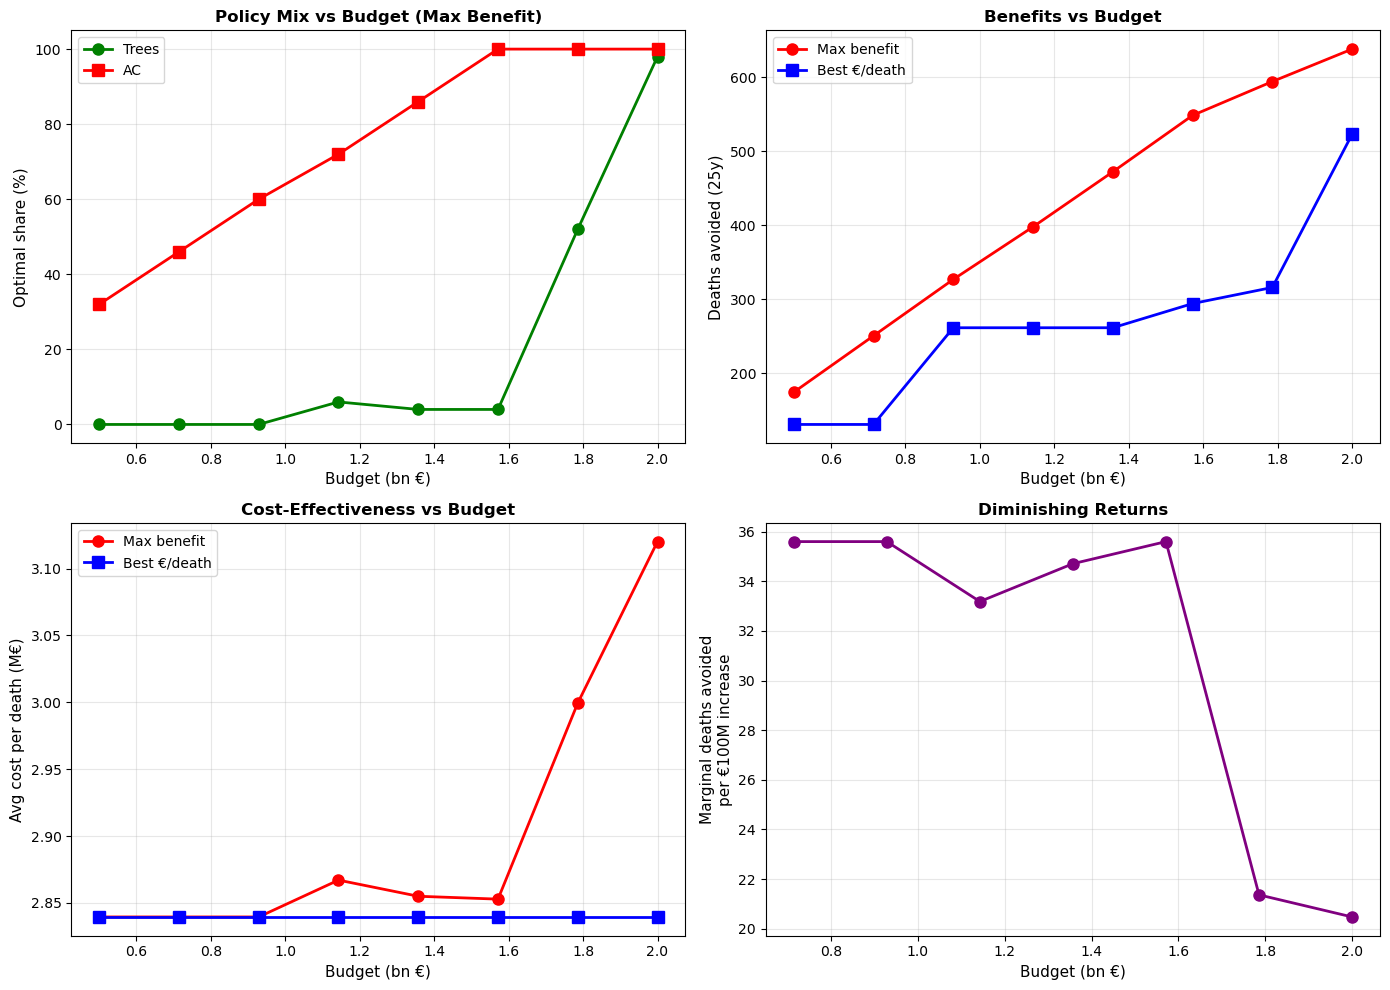

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# top-left: optimal policy mix vs budget (max benefit strategy)
axes[0, 0].plot(sens_df["budget"]/1e9, sens_df["max_ben_trees"]*100, 
                marker='o', linewidth=2, markersize=8, label='Trees', color='green')
axes[0, 0].plot(sens_df["budget"]/1e9, sens_df["max_ben_ac"]*100, 
                marker='s', linewidth=2, markersize=8, label='AC', color='red')
axes[0, 0].set_xlabel("Budget (bn €)", fontsize=11)
axes[0, 0].set_ylabel("Optimal share (%)", fontsize=11)
axes[0, 0].set_title("Policy Mix vs Budget (Max Benefit)", fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(alpha=0.3)

# top-right: deaths avoided vs budget
axes[0, 1].plot(sens_df["budget"]/1e9, sens_df["max_benefit"],
                marker='o', linewidth=2, markersize=8, label='Max benefit', color='red')
axes[0, 1].plot(sens_df["budget"]/1e9, sens_df["best_ce_benefit"],
                marker='s', linewidth=2, markersize=8, label='Best €/death', color='blue')
axes[0, 1].set_xlabel("Budget (bn €)", fontsize=11)
axes[0, 1].set_ylabel("Deaths avoided (25y)", fontsize=11)
axes[0, 1].set_title("Benefits vs Budget", fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(alpha=0.3)

# bottom-left: average cost per death vs budget
sens_df["max_avg_ce"] = sens_df["max_cost"] / sens_df["max_benefit"]
sens_df["best_avg_ce"] = sens_df["best_ce_cost"] / sens_df["best_ce_benefit"]

axes[1, 0].plot(sens_df["budget"]/1e9, sens_df["max_avg_ce"]/1e6,
                marker='o', linewidth=2, markersize=8, label='Max benefit', color='red')
axes[1, 0].plot(sens_df["budget"]/1e9, sens_df["best_avg_ce"]/1e6,
                marker='s', linewidth=2, markersize=8, label='Best €/death', color='blue')
axes[1, 0].set_xlabel("Budget (bn €)", fontsize=11)
axes[1, 0].set_ylabel("Avg cost per death (M€)", fontsize=11)
axes[1, 0].set_title("Cost-Effectiveness vs Budget", fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(alpha=0.3)

# bottom-right: marginal benefit (additional deaths per additional €100M)
sens_df["marginal_benefit"] = sens_df["max_benefit"].diff() / (sens_df["budget"].diff() / 1e8)

axes[1, 1].plot(sens_df["budget"].iloc[1:]/1e9, sens_df["marginal_benefit"].iloc[1:],
                marker='o', linewidth=2, markersize=8, color='purple')
axes[1, 1].set_xlabel("Budget (bn €)", fontsize=11)
axes[1, 1].set_ylabel("Marginal deaths avoided\nper €100M increase", fontsize=11)
axes[1, 1].set_title("Diminishing Returns", fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Sensitivity analysis across budget levels**

Tests optimal mixes across multiple budget levels. Shows how strategy changes with available funds. 

In [39]:
def sensitivity_to_budget(budgets, grid_step=0.01, min_benefit_frac=0.5):
    """
    Evaluating optimal mixes across different budget levels.
    
    Returns DataFrame with optimal solutions at each budget.
    """
    results = []
    
    for budget in budgets:
        res_b = search_optimal_mix(budget, grid_step=grid_step, 
                                   min_benefit_frac_for_ce=min_benefit_frac)
        
        results.append({
            "budget": budget,
            "max_ben_trees": res_b["max_ben_row"]["share_trees"],
            "max_ben_ac": res_b["max_ben_row"]["share_ac"],
            "max_benefit": res_b["max_ben_row"]["benefit_deaths"],
            "max_cost": res_b["max_ben_row"]["PV_cost"],
            "best_ce_trees": res_b["best_ce_row"]["share_trees"],
            "best_ce_ac": res_b["best_ce_row"]["share_ac"],
            "best_ce_benefit": res_b["best_ce_row"]["benefit_deaths"],
            "best_ce_cost": res_b["best_ce_row"]["PV_cost"],
        })
    
    return pd.DataFrame(results)


print("\n" + "="*80)
print("BUDGET SENSITIVITY ANALYSIS")
print("="*80)
print("Testing optimal mixes across different budget levels...\n")

# defining budget range
budgets = np.linspace(500e6, 2000e6, 8)  # 500M to 2B €

# running sensitivity analysis
sens_df = sensitivity_to_budget(budgets, grid_step=0.02)  # coarser grid for speed

print("\nOptimal mixes across budgets:")
print(sens_df.to_string(index=False))


BUDGET SENSITIVITY ANALYSIS
Testing optimal mixes across different budget levels...

[Budget search] Feasible combos: 476 under PV budget = €500,000,000
[Budget search] Feasible combos: 829 under PV budget = €714,285,714
[Budget search] Feasible combos: 1182 under PV budget = €928,571,429
[Budget search] Feasible combos: 1535 under PV budget = €1,142,857,143
[Budget search] Feasible combos: 1888 under PV budget = €1,357,142,857
[Budget search] Feasible combos: 2241 under PV budget = €1,571,428,571
[Budget search] Feasible combos: 2503 under PV budget = €1,785,714,286
[Budget search] Feasible combos: 2600 under PV budget = €2,000,000,000

Optimal mixes across budgets:
      budget  max_ben_trees  max_ben_ac  max_benefit     max_cost  best_ce_trees  best_ce_ac  best_ce_benefit  best_ce_cost
5.000000e+08           0.00        0.32   174.372783 4.951338e+08            0.0        0.24       130.779587  3.713503e+08
7.142857e+08           0.00        0.46   250.660875 7.117548e+08          

**Policy constraints**

3 scenarios: unconstrained, min trees, max AC. Quantifies cost of political constraints. 

In [43]:
def search_with_constraints(
    PV_budget: float,
    min_trees_share: float = 0.0,
    max_ac_share: float = 1.0,
    grid_step: float = 0.01,
):
    """
    Search with additional policy constraints.
    
    Example constraints:
    - min_trees_share: Political requirement to plant some trees (co-benefits)
    - max_ac_share: Equity constraint to limit AC subsidies
    """
    grid = np.arange(0.0, 1.0 + 1e-9, grid_step)
    
    rows = []
    for sT in grid:
        for sA in grid:
            # check constraints
            if sT < min_trees_share:
                continue
            if sA > max_ac_share:
                continue
            
            cost, ben = eval_mix(sT, sA)
            if cost <= PV_budget:
                rows.append({
                    "share_trees": sT,
                    "share_ac": sA,
                    "PV_cost": cost,
                    "benefit_deaths": ben,
                    "cost_per_death": cost / ben if ben > 0 else np.nan,
                })
    
    mix_df = pd.DataFrame(rows)
    
    if mix_df.empty:
        raise ValueError("No feasible combos under these constraints.")
    
    # finding optimal
    max_idx = mix_df["benefit_deaths"].idxmax()
    max_ben_row = mix_df.loc[max_idx]
    
    return {
        "mix_df": mix_df,
        "max_ben_row": max_ben_row,
    }


print("\n" + "="*80)
print("POLICY CONSTRAINT ANALYSIS")
print("="*80)

# Scenario 1: unconstrained (our baseline)
print("\n[Scenario 1] Unconstrained optimization:")
print(f"  Optimal: {opt_max['share_trees']*100:.0f}% trees + {opt_max['share_ac']*100:.0f}% AC")
print(f"  Deaths avoided: {opt_max['benefit_deaths']:.1f}")
print(f"  Cost: €{opt_max['PV_cost']/1e9:.2f}B")

# Scenario 2: must plant at least 20% of trees (political constraint)
const1 = search_with_constraints(PV_budget, min_trees_share=0.20)
opt_const1 = const1["max_ben_row"]
print(f"\n[Scenario 2] Minimum 20% trees (political constraint):")
print(f"  Optimal: {opt_const1['share_trees']*100:.0f}% trees + {opt_const1['share_ac']*100:.0f}% AC")
print(f"  Deaths avoided: {opt_const1['benefit_deaths']:.1f}")
print(f"  Cost: €{opt_const1['PV_cost']/1e9:.2f}B")
print(f"  Cost of constraint: {opt_max['benefit_deaths'] - opt_const1['benefit_deaths']:.1f} fewer deaths avoided")

# Scenario 3: limiting AC to 70% (equity constraint)
const2 = search_with_constraints(PV_budget, max_ac_share=0.70)
opt_const2 = const2["max_ben_row"]
print(f"\n[Scenario 3] Maximum 70% AC (equity constraint):")
print(f"  Optimal: {opt_const2['share_trees']*100:.0f}% trees + {opt_const2['share_ac']*100:.0f}% AC")
print(f"  Deaths avoided: {opt_const2['benefit_deaths']:.1f}")
print(f"  Cost: €{opt_const2['PV_cost']/1e9:.2f}B")
print(f"  Cost of constraint: {opt_max['benefit_deaths'] - opt_const2['benefit_deaths']:.1f} fewer deaths avoided")


POLICY CONSTRAINT ANALYSIS

[Scenario 1] Unconstrained optimization:
  Optimal: 3% trees + 96% AC
  Deaths avoided: 526.0
  Cost: €1.50B

[Scenario 2] Minimum 20% trees (political constraint):
  Optimal: 20% trees + 91% AC
  Deaths avoided: 514.9
  Cost: €1.50B
  Cost of constraint: 11.0 fewer deaths avoided

[Scenario 3] Maximum 70% AC (equity constraint):
  Optimal: 95% trees + 69% AC
  Deaths avoided: 466.6
  Cost: €1.50B
  Cost of constraint: 59.4 fewer deaths avoided


**Cost-Effectiveness Curve**

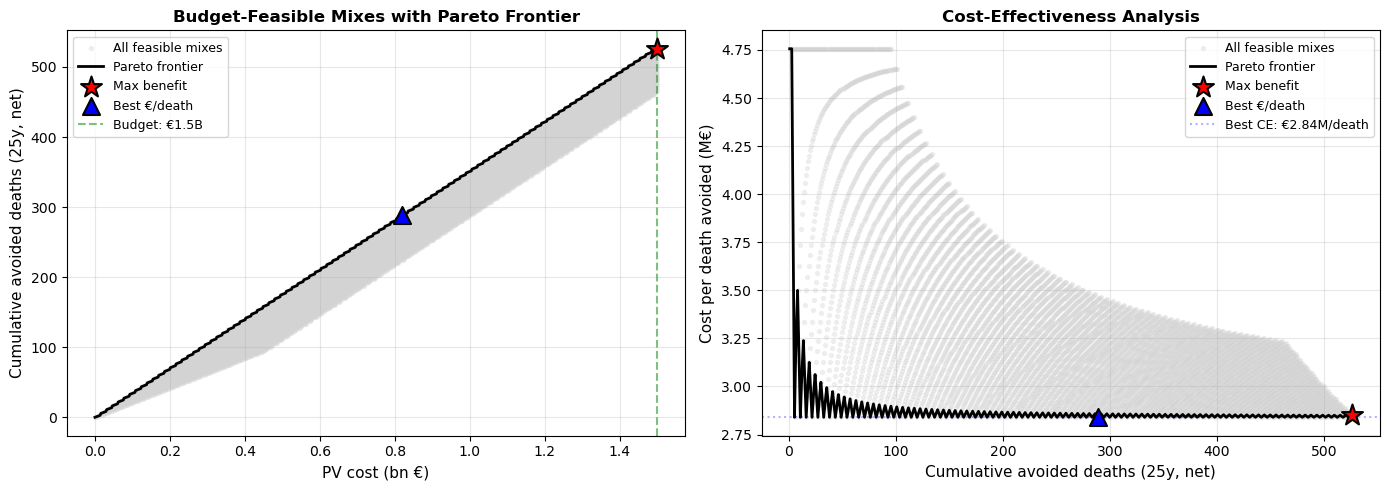

In [44]:
mix_df = res["mix_df"]
opt_max = res["max_ben_row"]
opt_ce = res["best_ce_row"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: Cost vs Benefit with Pareto frontier
axes[0].scatter(
    mix_df["PV_cost"]/1e9,
    mix_df["benefit_deaths"],
    s=8,
    alpha=0.3,
    c='lightgray',
    label='All feasible mixes'
)

# pareto frontier
axes[0].plot(
    pareto_df["PV_cost"]/1e9,
    pareto_df["benefit_deaths"],
    'k-',
    linewidth=2,
    label='Pareto frontier',
    zorder=4
)

# optimal points
axes[0].scatter(
    opt_max["PV_cost"]/1e9,
    opt_max["benefit_deaths"],
    marker="*",
    s=250,
    c='red',
    edgecolors='black',
    linewidths=1.5,
    label="Max benefit",
    zorder=5
)

axes[0].scatter(
    opt_ce["PV_cost"]/1e9,
    opt_ce["benefit_deaths"],
    marker="^",
    s=150,
    c='blue',
    edgecolors='black',
    linewidths=1.5,
    label="Best €/death",
    zorder=5
)

# budget line
axes[0].axvline(x=PV_budget/1e9, color='green', linestyle='--', 
                alpha=0.5, label=f'Budget: €{PV_budget/1e9:.1f}B')

axes[0].set_xlabel("PV cost (bn €)", fontsize=11)
axes[0].set_ylabel("Cumulative avoided deaths (25y, net)", fontsize=11)
axes[0].set_title("Budget-Feasible Mixes with Pareto Frontier", fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

# right: Cost per death vs total deaths
axes[1].scatter(
    mix_df["benefit_deaths"],
    mix_df["cost_per_death"]/1e6,
    s=8,
    alpha=0.3,
    c='lightgray',
    label='All feasible mixes'
)

# Pareto frontier
axes[1].plot(
    pareto_df["benefit_deaths"],
    pareto_df["cost_per_death"]/1e6,
    'k-',
    linewidth=2,
    label='Pareto frontier',
    zorder=4
)

# Optimal points
axes[1].scatter(
    opt_max["benefit_deaths"],
    opt_max["cost_per_death"]/1e6,
    marker="*",
    s=250,
    c='red',
    edgecolors='black',
    linewidths=1.5,
    label="Max benefit",
    zorder=5
)

axes[1].scatter(
    opt_ce["benefit_deaths"],
    opt_ce["cost_per_death"]/1e6,
    marker="^",
    s=150,
    c='blue',
    edgecolors='black',
    linewidths=1.5,
    label="Best €/death",
    zorder=5
)

# ref line
axes[1].axhline(
    y=opt_ce["cost_per_death"]/1e6,
    color='blue',
    linestyle=':',
    alpha=0.3,
    label=f'Best CE: €{opt_ce["cost_per_death"]/1e6:.2f}M/death'
)

axes[1].set_xlabel("Cumulative avoided deaths (25y, net)", fontsize=11)
axes[1].set_ylabel("Cost per death avoided (M€)", fontsize=11)
axes[1].set_title("Cost-Effectiveness Analysis", fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Summary table**

In [45]:
print("\n" + "="*80)
print("SUMMARY TABLE FOR PUBLICATION")
print("="*80)

summary = pd.DataFrame([
    {
        "Strategy": "Full Trees",
        "Trees (%)": 100,
        "AC (%)": 0,
        "PV Cost (M€)": PV_tree_unit / 1e6,
        "Deaths Avoided": BEN_tree_unit,
        "€/Death (M€)": (PV_tree_unit / BEN_tree_unit) / 1e6,
    },
    {
        "Strategy": "Full AC",
        "Trees (%)": 0,
        "AC (%)": 100,
        "PV Cost (M€)": PV_ac_unit / 1e6,
        "Deaths Avoided": BEN_ac_unit,
        "€/Death (M€)": (PV_ac_unit / BEN_ac_unit) / 1e6,
    },
    {
        "Strategy": "Max Benefit (Budget)",
        "Trees (%)": opt_max["share_trees"] * 100,
        "AC (%)": opt_max["share_ac"] * 100,
        "PV Cost (M€)": opt_max["PV_cost"] / 1e6,
        "Deaths Avoided": opt_max["benefit_deaths"],
        "€/Death (M€)": (opt_max["PV_cost"] / opt_max["benefit_deaths"]) / 1e6,
    },
    {
        "Strategy": "Best €/Death (Budget)",
        "Trees (%)": opt_ce["share_trees"] * 100,
        "AC (%)": opt_ce["share_ac"] * 100,
        "PV Cost (M€)": opt_ce["PV_cost"] / 1e6,
        "Deaths Avoided": opt_ce["benefit_deaths"],
        "€/Death (M€)": (opt_ce["PV_cost"] / opt_ce["benefit_deaths"]) / 1e6,
    },
])

print("\n")
print(summary.to_string(index=False))

# exporting to CSV
summary.to_csv("budget_optimization_summary.csv", index=False)
print("\n✓ Summary exported to: budget_optimization_summary.csv")


SUMMARY TABLE FOR PUBLICATION


             Strategy  Trees (%)  AC (%)  PV Cost (M€)  Deaths Avoided  €/Death (M€)
           Full Trees      100.0     0.0    453.654752       95.379855      4.756295
              Full AC        0.0   100.0   1547.293100      544.914946      2.839513
 Max Benefit (Budget)        3.0    96.0   1499.011018      525.979744      2.849941
Best €/Death (Budget)        0.0    53.0    820.065343      288.804922      2.839513

✓ Summary exported to: budget_optimization_summary.csv


**Cost-Effectiveness**
- AC dominates trees:
    - Full Trees: €4.75M per death avoided
    - Full AC: €2.84M per death avoided
    - AC is 1.67× more cost-effective

- Under €1.5B Budget:
    - Trees alone: 95 deaths avoided (€454M cost)
    - AC alone: 544 deaths avoided (€1,547M cost)
    - AC saves 5.7× more lives

- To save maximum lives with €1.5B → use nearly all on AC
- To minimize cost per death → use only AC (save €680M)
- Trees only appear when there's spare budget

- Only 4.6% of Mixes Are Efficient
- Out of 8,361 feasible combinations:
    - 388 are Pareto-optimal (can't improve without tradeoff)
    - 7,973 are dominated (wasteful)

- Political Constraints Are Costly
- Scenario: Must plant 20% of trees
    - Optimal becomes: 20% trees + 91% AC
    - Result: 515 deaths avoided (vs 526 unconstrained)
    - Cost: 11 additional deaths
- Scenario: Limit AC to 70%
    - Optimal becomes: 95% trees + 69% AC
    - Result: 467 deaths avoided (vs 526 unconstrained)
    - Cost: 59 additional deaths

Next step we could:
- Non-Linear Returns
- Uncertainty Analysis (Monte Carlo sampling of costs/benefits, anyway it was advised by Johannes...)
- Multi-objective optimization (was our first goal!) => absolutely need to add it
- spatial targeting

**some findings from this**:
- AC subsidies should be the primary heat adaptation strategy in Rome
    - AC is 1.67× more cost-effective than trees
    - Under any realistic budget, optimal mix heavily favors AC (53-96%)
    - Trees only appear when: Budget has slack after maxing out AC, OR Political
      constraints force tree planting
- Budget matters: 
    - At low budgets (<€820M): Pure AC is optimal
    - At high budgets (€1.5B+): Small tree component appears
    - Diminishing returns visible in ICER analysis

- Political constraints have real costs
    - Requiring 20% trees → 11 additional deaths
    - Limiting AC to 70% → 59 additional deaths

- Co-Benefits argument:
    - CAREFUL: trees have significant co-benefits (while AC : contrary) 